In [1]:
# ============================================================
# Cell 1 — MUST run first (before numpy/scipy/skimage/numba)
# Auto thread setup + optional auto "cd .." if inside analysis/
# ============================================================
import os
from pathlib import Path

# ---------- Threading (auto) ----------
cpu = os.cpu_count() or 4
N_THREADS = max(1, cpu - 1)

os.environ["NUMBA_THREADING_LAYER"] = os.environ.get("NUMBA_THREADING_LAYER", "workqueue")
os.environ["OMP_NUM_THREADS"]        = str(int(os.environ.get("OMP_NUM_THREADS", N_THREADS)))
os.environ["OMP_MAX_ACTIVE_LEVELS"]  = os.environ.get("OMP_MAX_ACTIVE_LEVELS", "1")
os.environ["MKL_NUM_THREADS"]        = str(int(os.environ.get("MKL_NUM_THREADS", N_THREADS)))
os.environ["OPENBLAS_NUM_THREADS"]   = str(int(os.environ.get("OPENBLAS_NUM_THREADS", N_THREADS)))
os.environ["NUMEXPR_NUM_THREADS"]    = str(int(os.environ.get("NUMEXPR_NUM_THREADS", N_THREADS)))
os.environ["KMP_WARNINGS"]           = os.environ.get("KMP_WARNINGS", "0")

print("[env] cpu_count =", cpu)
print("[env] using threads =", os.environ["OMP_NUM_THREADS"])
print("[env] NUMBA_THREADING_LAYER =", os.environ["NUMBA_THREADING_LAYER"])

# ---------- Optional: auto set project root ----------
cwd = Path.cwd().resolve()
# If user runs notebook under ".../analysis", automatically chdir to parent
if cwd.name.lower() == "analysis":
    os.chdir(str(cwd.parent))
    cwd = Path.cwd().resolve()
print("[cwd]", cwd)

# Now safe to import the rest
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

[env] cpu_count = 24
[env] using threads = 23
[env] NUMBA_THREADING_LAYER = workqueue
[cwd] /Users/fengshuoliu/Library/CloudStorage/OneDrive-BaylorCollegeofMedicine/Lab/Zhan/image_analysis_pip


In [2]:
# ============================================================
# Cell 2 — Interactive configuration (Jupyter) [UPDATED v4]
# Change requested:
# - Remove the "≤3" overlay channel limit in the UI.
#   -> Overlay selection now allows ANY number of channels.
#   -> (Note) Your current Cell 3 overlay function is still "up to 3".
#      If you want true N-channel overlay, also replace Cell 3 overlay with the
#      provided helper at the bottom of this cell.
# ============================================================

from pathlib import Path
import os

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except Exception as e:
    raise RuntimeError(
        "ipywidgets is required for the interactive UI.\n"
        "Install with: pip install ipywidgets\n"
        "Then restart the kernel."
    ) from e

# -----------------------------
# Folder autocomplete (relative)
# -----------------------------
ROOT = Path.cwd().resolve()

def _iter_subdirs_relative(root: Path, max_depth: int = 5, limit: int = 1200):
    root = root.resolve()
    out = []
    stack = [(root, 0)]
    while stack and len(out) < limit:
        cur, depth = stack.pop(0)
        if depth >= max_depth:
            continue
        try:
            for p in sorted(cur.iterdir()):
                if p.is_dir() and not p.name.startswith("."):
                    rel = p.resolve().relative_to(root).as_posix()
                    out.append(rel)
                    if len(out) >= limit:
                        break
                    stack.append((p, depth + 1))
        except Exception:
            continue
    return out

ALL_REL_DIRS = _iter_subdirs_relative(ROOT, max_depth=5, limit=1200)

def _suggest_rel_dirs(prefix: str, limit: int = 200):
    s = (prefix or "").strip().replace("\\", "/")
    if not s:
        return ALL_REL_DIRS[:limit]
    s_low = s.lower()
    return [d for d in ALL_REL_DIRS if d.lower().startswith(s_low)][:limit]

def _resolve_folder(val: str) -> Path:
    v = (val or "").strip()
    if not v:
        return ROOT
    p = Path(v).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (ROOT / p).resolve()

# -----------------------------
# 50+ preset colors (palette)
# -----------------------------
def _rgb_to_hex(r, g, b):
    return "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))

def _generate_distinct_hex(n=72, s=0.78, v=0.95):
    import colorsys
    cols = []
    for i in range(n):
        r, g, b = colorsys.hsv_to_rgb(i / float(n), s, v)
        cols.append(_rgb_to_hex(r, g, b))
    return cols

COLOR_HEX_LIST = _generate_distinct_hex(n=72, s=0.78, v=0.95)
COMMON_FIRST = ["#dc0000", "#00ff00", "#0008e5", "#ffffff", "#ff00ff", "#00ffff", "#ffff00"]
COLOR_HEX_LIST = list(dict.fromkeys(COMMON_FIRST + COLOR_HEX_LIST))  # unique, keep order

# -----------------------------
# Helpers
# -----------------------------
def _list_text_image_files(folder: Path):
    exts = (".csv", ".txt")
    return sorted([p.name for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts])

def _stem_no_ext(fname: str):
    return Path(fname).stem

# ============================================================
# UI widgets
# ============================================================
default_rel = "data/demo1" if (ROOT / "data" / "demo1").exists() else ""
folder_box = widgets.Combobox(
    value=default_rel,
    placeholder="Type relative folder under current directory (TAB for suggestions)…",
    options=_suggest_rel_dirs(default_rel),
    description="Folder:",
    ensure_option=False,
    layout=widgets.Layout(width="85%")
)
refresh_btn = widgets.Button(description="Load folder files", button_style="info")
folder_out = widgets.Output()

def _refresh_folder_options(_=None):
    folder_box.options = _suggest_rel_dirs(folder_box.value)

folder_box.observe(_refresh_folder_options, names="value")

n_channels = widgets.BoundedIntText(value=3, min=1, max=20, step=1, description="#Channels:")
build_btn = widgets.Button(description="Build channel selectors", button_style="primary")
channels_box = widgets.VBox([])
channels_out = widgets.Output()

# Pixel size inputs (defaults 0.0 / 0; no bounds)
x_um = widgets.FloatText(value=0.0, description="x (µm):")
x_px = widgets.IntText(value=0, description="x (px):")
y_um = widgets.FloatText(value=0.0, description="y (µm):")
y_px = widgets.IntText(value=0, description="y (px):")
pixel_out = widgets.Output()

# Overlay selection (NO LIMIT now): choose ANY number of channels + optional white overlay
overlay_select = widgets.SelectMultiple(options=[], value=(), description="Overlay:", rows=8)
white_dropdown = widgets.Dropdown(options=["None"], value="None", description="White:")
white_weight = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.05, description="White w:")

save_btn = widgets.Button(description="Save CONFIG", button_style="success")
config_out = widgets.Output()

CFG = {}
AVAILABLE_FILES = []
channel_rows = []

# ============================================================
# Color palette panel (clickable actual colors)
# ============================================================
palette_target = {"picker": None, "swatch": None}

palette_title = widgets.HTML("<b>Palette:</b> click a color to apply (select a channel with 🎨)")
palette_close = widgets.Button(description="Close palette", button_style="")
palette_panel = widgets.VBox([])
palette_panel.layout.display = "none"

def _hide_palette(_=None):
    palette_panel.layout.display = "none"
    palette_target["picker"] = None
    palette_target["swatch"] = None

palette_close.on_click(_hide_palette)

palette_buttons = []
for hexv in COLOR_HEX_LIST:
    b = widgets.Button(description="", tooltip=hexv, layout=widgets.Layout(width="22px", height="22px", padding="0px", margin="1px"))
    b.style.button_color = hexv

    def _make_onclick(hex_color):
        def _onclick(_btn):
            if palette_target["picker"] is None:
                return
            palette_target["picker"].value = hex_color
            if palette_target["swatch"] is not None:
                palette_target["swatch"].value = (
                    f"<div style='display:inline-block;width:70px;height:18px;"
                    f"border:1px solid #999;background:{hex_color};'></div> <code>{hex_color}</code>"
                )
        return _onclick

    b.on_click(_make_onclick(hexv))
    palette_buttons.append(b)

palette_grid = widgets.GridBox(children=palette_buttons, layout=widgets.Layout(grid_template_columns="repeat(12, 24px)", align_items="center"))
palette_panel.children = [palette_title, palette_grid, palette_close]

# ============================================================
# Callbacks
# ============================================================
def on_refresh(_):
    global AVAILABLE_FILES
    with folder_out:
        clear_output()
        folder = _resolve_folder(folder_box.value)
        if not folder.exists() or not folder.is_dir():
            print("❌ Folder not found:", folder)
            AVAILABLE_FILES = []
            return
        AVAILABLE_FILES = _list_text_image_files(folder)
        print("✅ Folder:", folder)
        print("Found CSV/TXT files:")
        for f in AVAILABLE_FILES:
            print("  -", f)

refresh_btn.on_click(on_refresh)

def on_build(_):
    global channel_rows
    channel_rows = []
    if not AVAILABLE_FILES:
        with channels_out:
            clear_output()
            print("❌ Please click 'Load folder files' first.")
        return

    rows = []
    for i in range(int(n_channels.value)):
        file_dd = widgets.Dropdown(options=AVAILABLE_FILES, description=f"Ch {i+1} file:")
        marker_txt = widgets.Text(value=_stem_no_ext(AVAILABLE_FILES[0]), description="Marker:", layout=widgets.Layout(width="40%"))

        color_picker = widgets.ColorPicker(
            concise=True,
            description="",
            value=COMMON_FIRST[min(i, len(COMMON_FIRST)-1)] if COMMON_FIRST else COLOR_HEX_LIST[0]
        )
        pick_palette_btn = widgets.Button(description="🎨", tooltip="Pick from palette", layout=widgets.Layout(width="40px"))
        swatch = widgets.HTML(value="")

        def _update_marker(change=None, file_dd=file_dd, marker_txt=marker_txt):
            marker_txt.value = _stem_no_ext(file_dd.value)

        def _update_swatch(change=None, color_picker=color_picker, swatch=swatch):
            hexv = str(color_picker.value)
            swatch.value = (
                f"<div style='display:inline-block;width:70px;height:18px;"
                f"border:1px solid #999;background:{hexv};'></div> <code>{hexv}</code>"
            )

        def _open_palette(_btn, color_picker=color_picker, swatch=swatch):
            palette_target["picker"] = color_picker
            palette_target["swatch"] = swatch
            palette_panel.layout.display = "block"

        file_dd.observe(_update_marker, names="value")
        color_picker.observe(_update_swatch, names="value")
        pick_palette_btn.on_click(_open_palette)

        _update_swatch()

        row = widgets.HBox([file_dd, marker_txt, color_picker, pick_palette_btn, swatch])
        rows.append(row)
        channel_rows.append({"file": file_dd, "marker": marker_txt, "color": color_picker})

    channels_box.children = rows

    with channels_out:
        clear_output()
        print("✅ Channel selectors built. Choose file/marker/color for each channel.")
        print("Tip: click 🎨 on a channel row, then click a palette color to apply.")

build_btn.on_click(on_build)

def on_pixel_change(_=None):
    with pixel_out:
        clear_output()
        if int(x_px.value) <= 0 or int(y_px.value) <= 0:
            print("Enter x (px) and y (px) > 0 to compute PIXEL_SIZE_UM")
            return
        px_um = (float(x_um.value) / int(x_px.value), float(y_um.value) / int(y_px.value))
        print("Computed PIXEL_SIZE_UM = (x_um/x_px, y_um/y_px)")
        print("PIXEL_SIZE_UM =", px_um)

for w in (x_um, x_px, y_um, y_px):
    w.observe(on_pixel_change, names="value")
on_pixel_change()

def on_save(_):
    global CFG
    folder = _resolve_folder(folder_box.value)
    if not folder.exists():
        with config_out:
            clear_output()
            print("❌ Folder not found:", folder)
        return
    if not channel_rows:
        with config_out:
            clear_output()
            print("❌ Build channel selectors first.")
        return
    if int(x_px.value) <= 0 or int(y_px.value) <= 0:
        with config_out:
            clear_output()
            print("❌ x (px) and y (px) must be > 0")
        return

    ch_cfg = []
    for row in channel_rows:
        fname = row["file"].value
        marker = row["marker"].value.strip() or _stem_no_ext(fname)
        color_hex = str(row["color"].value)
        ch_cfg.append({"file": fname, "channel": marker, "color_hex": color_hex})

    pixel_size_um = (float(x_um.value) / int(x_px.value), float(y_um.value) / int(y_px.value))

    save_dir = folder / "outs"
    save_dir.mkdir(parents=True, exist_ok=True)

    channel_names = [c["channel"] for c in ch_cfg]

    # NO LIMIT now: default overlay selects ALL channels
    overlay_select.options = channel_names
    overlay_select.value = tuple(channel_names)

    white_dropdown.options = ["None"] + channel_names
    white_dropdown.value = "None"
    white_weight.value = 0.0

    CFG = {
        "FOLDER": folder,
        "SAVE_DIR": save_dir,
        "PIXEL_SIZE_UM": pixel_size_um,
        "IMAGE_ID": "FieldA",
        "CHANNELS": ch_cfg,
        # overlay selection read live by Cell 3
    }

    with config_out:
        clear_output()
        print("✅ CONFIG saved:")
        print("ROOT     =", ROOT)
        print("FOLDER   =", CFG["FOLDER"])
        print("SAVE_DIR =", CFG["SAVE_DIR"])
        print("PIXEL_SIZE_UM =", CFG["PIXEL_SIZE_UM"], "   (x_um/x_px, y_um/y_px)")
        print("Channels:")
        for c in CFG["CHANNELS"]:
            print(f"  - {c['channel']}: file={c['file']}  color={c['color_hex']}")
        print("\nOverlay selection now has NO limit (can select any number of channels).")

save_btn.on_click(on_save)

# ============================================================
# Display UI
# ============================================================
display(widgets.VBox([
    widgets.HBox([folder_box, refresh_btn]),
    folder_out,
    widgets.HBox([n_channels, build_btn]),
    channels_box,
    channels_out,
    palette_panel,
    widgets.HTML("<hr><b>Pixel size (IMPORTANT):</b> PIXEL_SIZE_UM = (x_um/x_px, y_um/y_px)"),
    widgets.HBox([x_um, x_px, y_um, y_px]),
    pixel_out,
    widgets.HTML("<hr><b>Overlay options (optional):</b> choose any number of channels + optional white overlay"),
    widgets.HBox([overlay_select, widgets.VBox([white_dropdown, white_weight])]),
    widgets.HBox([save_btn]),
    config_out
]))

# ============================================================
# IMPORTANT NOTE:
# Your CURRENT Cell 3 overlay function was written for up to 3 channels.
# If you truly want N-channel overlay, replace that overlay function with
# a generalized version that sums all selected channels by their chosen colors.
# If you want, tell me and I'll paste the exact Cell 3 replacement.
# ============================================================

Loading from: /Users/fengshuoliu/Library/CloudStorage/OneDrive-BaylorCollegeofMedicine/Lab/Zhan/image_analysis_pip/data/demo2
  image_id channel  y_px  x_px  value      x_um  y_um
0   FieldA  biotin     0     0    0.0  0.000000   0.0
1   FieldA  biotin     0     1    0.0  0.342972   0.0
2   FieldA  biotin     0     2    0.0  0.685945   0.0
Loaded 124,555,581 pixels from 3 channel files.
Channels: ['biotin', 'tumor', 'DAPI']
Saved: /Users/fengshuoliu/Library/CloudStorage/OneDrive-BaylorCollegeofMedicine/Lab/Zhan/image_analysis_pip/data/demo2/outs/overlay.svg


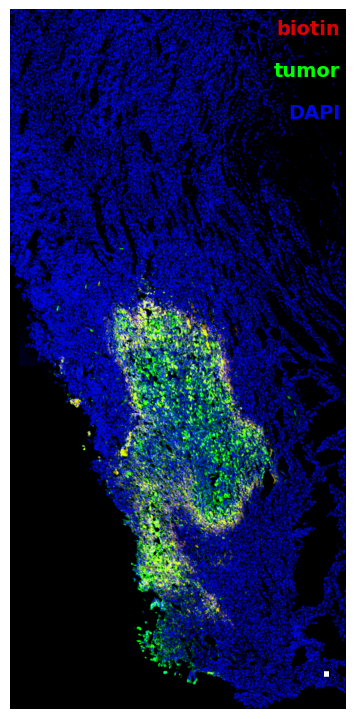

Saved: /Users/fengshuoliu/Library/CloudStorage/OneDrive-BaylorCollegeofMedicine/Lab/Zhan/image_analysis_pip/data/demo2/outs/split_channels.svg


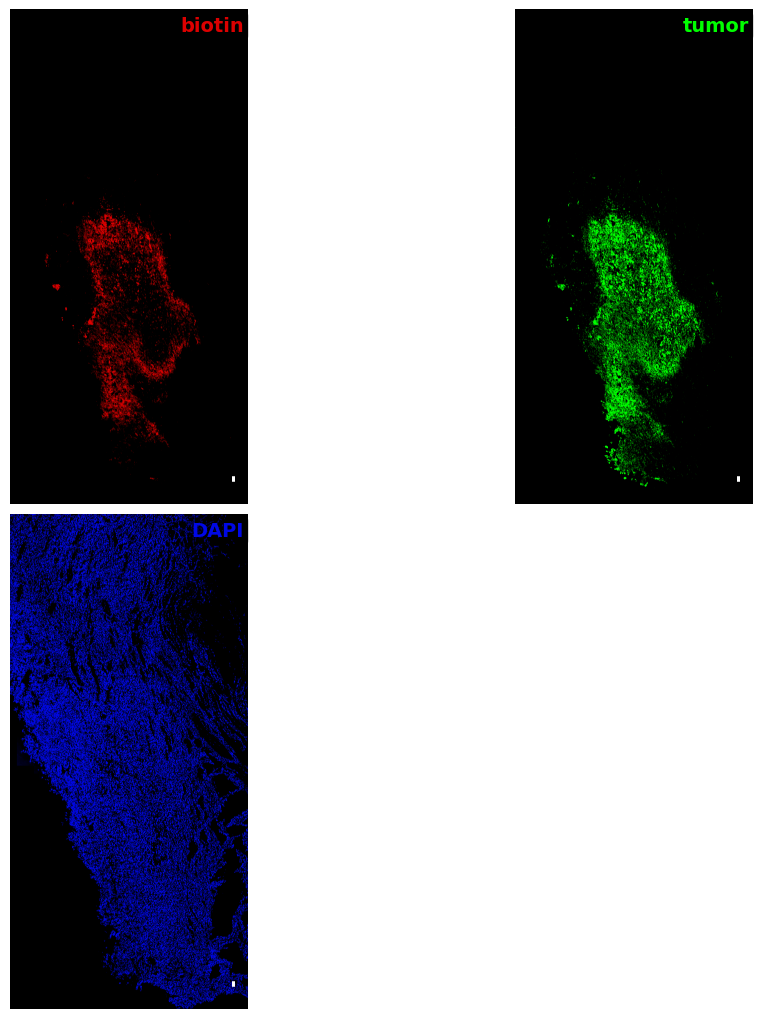

Done. Outputs saved to: /Users/fengshuoliu/Library/CloudStorage/OneDrive-BaylorCollegeofMedicine/Lab/Zhan/image_analysis_pip/data/demo2/outs


In [9]:
# ============================================================
# Cell 3 — Load selected CSV/TXT files, build long df, plot & save
# UPDATED: overlay.svg now supports ANY number of channels (multi-channel screen blend)
# Style: no axes/border, colored channel names top-right, 20 µm white scalebar bottom-right
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---------- Helpers ----------
def _valid_pixel_size(ps):
    try:
        return ps is not None and len(ps) == 2 and float(ps[0]) > 0 and float(ps[1]) > 0
    except Exception:
        return False

def _load_text_grid(path: Path, dtype=np.float32) -> np.ndarray:
    with open(path, "r", errors="ignore") as f:
        first = f.readline()
    if "\t" in first:
        sep = "\t"
    elif "," in first:
        sep = ","
    elif ";" in first:
        sep = ";"
    else:
        sep = r"\s+"
    df = pd.read_csv(path, header=None, sep=sep, engine="python" if sep == r"\s+" else "c")
    return df.to_numpy(dtype=dtype, copy=False)

def files_to_long_df(folder: Path, channels_cfg, image_id="FieldA", pixel_size_um=None, unit="um"):
    """
    channels_cfg: list of dicts with keys:
      - file (filename in folder)
      - channel (marker/label)
      - color_hex
    """
    long_frames = []
    shapes = {}

    for c in channels_cfg:
        p = folder / c["file"]
        arr = _load_text_grid(p)
        h, w = arr.shape
        y_idx, x_idx = np.indices((h, w))

        df = pd.DataFrame({
            "image_id": image_id,
            "channel": str(c["channel"]),
            "y_px": y_idx.ravel(order="C").astype(np.int32),
            "x_px": x_idx.ravel(order="C").astype(np.int32),
            "value": arr.ravel(order="C")
        })
        if pixel_size_um is not None:
            df[f"x_{unit}"] = df["x_px"] * float(pixel_size_um[0])  # x first
            df[f"y_{unit}"] = df["y_px"] * float(pixel_size_um[1])  # y second

        long_frames.append(df)
        shapes[(image_id, str(c["channel"]))] = (h, w)

    return pd.concat(long_frames, ignore_index=True), shapes

def channels_by_image(df):
    return (df.groupby("image_id")["channel"].unique().apply(lambda x: list(map(str, x))))

def to_image(df, shapes, image_id: str, channel: str):
    key = (image_id, channel)
    if key not in shapes:
        raise KeyError(f"Missing {key}. Available channels: {channels_by_image(df).get(image_id, [])}")
    h, w = shapes[key]
    sub = df[(df["image_id"] == image_id) & (df["channel"] == channel)]
    return sub["value"].to_numpy().reshape(h, w)

def norm_clip(arr, lo_percentile=0.0, hi_percentile=99.8):
    a = arr.astype(float, copy=False)
    lo_v = np.nanpercentile(a, lo_percentile)
    hi_v = np.nanpercentile(a, hi_percentile)
    if hi_v <= lo_v:
        return np.zeros_like(a, dtype=float)
    a = (a - lo_v) / (hi_v - lo_v)
    return np.clip(a, 0, 1)

def hex_to_rgb01(hex_color: str):
    return np.array(mcolors.to_rgb(hex_color), dtype=float)

# ---------- Publication-style helpers ----------
def _axis_off(ax):
    ax.set_axis_off()
    ax.set_frame_on(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

def _add_scalebar_20um(ax, img_shape, px_um_x, bar_um=20.0, color="white", lw=4, pad_frac=0.05):
    if px_um_x is None or float(px_um_x) <= 0:
        return
    h, w = img_shape
    bar_px = int(round(float(bar_um) / float(px_um_x)))
    if bar_px <= 0:
        return
    pad_x = int(round(pad_frac * w))
    pad_y = int(round(pad_frac * h))
    x_end = w - pad_x
    x_start = max(pad_x, x_end - bar_px)
    y = h - pad_y
    ax.plot([x_start, x_end], [y, y], color=color, lw=lw, solid_capstyle="butt")

def _add_channel_labels(ax, names, hex_colors, x=0.985, y0=0.985):
    n = max(1, len(names))
    dy = min(0.06, 0.90 / n)
    fontsize = 14 if n <= 6 else max(8, int(14 * 6 / n))
    y = y0
    for nm, hx in zip(names, hex_colors):
        ax.text(
            x, y, nm,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=fontsize,
            fontweight="bold",
            color=hx,
            bbox=dict(boxstyle="round,pad=0.25", facecolor=(0, 0, 0, 0.25), edgecolor="none")
        )
        y -= dy

# ---------- Split channels (each panel colored) ----------
def plot_split_channels(df, shapes, image_id, channels_cfg, pixel_size_um=None, clip_hi=99.8, save_path=None):
    ch_names = [c["channel"] for c in channels_cfg]
    n = len(ch_names)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5 * nrows))
    axes = np.array(axes).ravel()

    px_um_x = pixel_size_um[0] if (_valid_pixel_size(pixel_size_um)) else None

    for ax, c in zip(axes, channels_cfg):
        ch = c["channel"]
        hx = c["color_hex"]

        img = norm_clip(to_image(df, shapes, image_id, ch), hi_percentile=clip_hi)
        rgb = np.clip(img[..., None] * hex_to_rgb01(hx), 0.0, 1.0)

        ax.imshow(rgb, origin="upper")
        _axis_off(ax)
        _add_channel_labels(ax, [ch], [hx])
        _add_scalebar_20um(ax, img.shape, px_um_x, bar_um=20.0, color="white", lw=4)

    for ax in axes[len(ch_names):]:
        ax.set_visible(False)

    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.02, hspace=0.02)

    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(save_path), dpi=600, bbox_inches="tight", pad_inches=0)
        print(f"Saved: {save_path.resolve()}")

    plt.show()
    plt.close(fig)

# ---------- Multi-channel overlay (ANY number of channels) ----------
def overlay_multi_channels(df, shapes, image_id, channels_cfg, overlay_channels,
                          white_channel=None, white_weight=0.0,
                          clip_hi=99.8, pixel_size_um=None, save_path=None):
    """
    Overlay ANY number of channels using SCREEN blend:
      rgb = 1 - Π(1 - layer_rgb)
    Optionally overlays one channel in WHITE with screen blend.
    """
    if overlay_channels is None or len(overlay_channels) == 0:
        raise ValueError("overlay_channels is empty.")

    # channel -> hex
    ch2hex = {c["channel"]: c["color_hex"] for c in channels_cfg}

    rgb = None
    h = w = None

    for ch in overlay_channels:
        if ch not in ch2hex:
            raise KeyError(f"Channel {ch!r} not found in channels_cfg.")
        img = norm_clip(to_image(df, shapes, image_id, ch), hi_percentile=clip_hi)
        if rgb is None:
            h, w = img.shape
            rgb = np.zeros((h, w, 3), dtype=float)

        layer = np.clip(img[..., None] * hex_to_rgb01(ch2hex[ch]), 0.0, 1.0)
        rgb = 1.0 - (1.0 - rgb) * (1.0 - layer)  # screen blend

    # optional white overlay
    if white_channel and white_channel != "None" and float(white_weight) > 0:
        wimg = norm_clip(to_image(df, shapes, image_id, white_channel), hi_percentile=clip_hi)
        wlayer = np.clip(float(white_weight) * wimg, 0.0, 1.0)[..., None]
        rgb = 1.0 - (1.0 - rgb) * (1.0 - wlayer)

    rgb = np.clip(rgb, 0.0, 1.0)

    px_um_x = pixel_size_um[0] if (_valid_pixel_size(pixel_size_um)) else None

    fig = plt.figure(figsize=(7, 7))
    ax = plt.gca()
    ax.imshow(rgb, origin="upper")
    _axis_off(ax)

    # labels top-right
    _add_channel_labels(ax, overlay_channels, [ch2hex[ch] for ch in overlay_channels])

    # 20 µm scalebar bottom-right
    _add_scalebar_20um(ax, (h, w), px_um_x, bar_um=20.0, color="white", lw=4)

    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(save_path), dpi=600, bbox_inches="tight", pad_inches=0)
        print(f"Saved: {save_path.resolve()}")

    plt.show()
    plt.close(fig)

# ---------- Run using CFG ----------
if "CFG" not in globals() or not CFG:
    raise RuntimeError("CFG is empty. Run Cell 2 and click 'Save CONFIG' first.")

FOLDER = Path(CFG["FOLDER"])
SAVE_DIR = Path(CFG["SAVE_DIR"])
PIXEL_SIZE_UM = CFG.get("PIXEL_SIZE_UM", None)
IMAGE_ID = CFG.get("IMAGE_ID", "FieldA")
CHANNELS_CFG = CFG.get("CHANNELS", [])

print("Loading from:", FOLDER)
df_pixels, shapes = files_to_long_df(
    folder=FOLDER,
    channels_cfg=CHANNELS_CFG,
    image_id=IMAGE_ID,
    pixel_size_um=PIXEL_SIZE_UM if _valid_pixel_size(PIXEL_SIZE_UM) else None,
    unit="um"
)

print(df_pixels.head(3))
print(f"Loaded {len(df_pixels):,} pixels from {len(CHANNELS_CFG)} channel files.")
print("Channels:", channels_by_image(df_pixels).get(IMAGE_ID, []))

# Overlay selection (read live from widgets created in Cell 2)
try:
    overlay_channels = list(overlay_select.value)
    white_ch = white_dropdown.value
    ww = float(white_weight.value)
except Exception:
    overlay_channels = [c["channel"] for c in CHANNELS_CFG]
    white_ch = "None"
    ww = 0.0

# if user selected nothing, overlay all
if not overlay_channels:
    overlay_channels = [c["channel"] for c in CHANNELS_CFG]

overlay_path = SAVE_DIR / "overlay.svg"
split_path   = SAVE_DIR / "split_channels.svg"

# 1) Overlay (ANY number of channels)
overlay_multi_channels(
    df_pixels, shapes, IMAGE_ID,
    channels_cfg=CHANNELS_CFG,
    overlay_channels=overlay_channels,
    white_channel=white_ch,
    white_weight=ww,
    clip_hi=99.8,
    pixel_size_um=PIXEL_SIZE_UM if _valid_pixel_size(PIXEL_SIZE_UM) else None,
    save_path=overlay_path
)

# 2) Split panels (all channels)
plot_split_channels(
    df_pixels, shapes, IMAGE_ID,
    channels_cfg=CHANNELS_CFG,
    pixel_size_um=PIXEL_SIZE_UM if _valid_pixel_size(PIXEL_SIZE_UM) else None,
    clip_hi=99.8,
    save_path=split_path
)

print("Done. Outputs saved to:", SAVE_DIR)

In [ ]:
# ============================
# NUCLEI SEGMENTATION (NUCLEAR CHANNEL) — ORIGINAL-LOGIC + TUNING UI
# CFG-compatible, but preserves original segmentation behavior as closely as possible
# ============================
# Prereqs:
#   df_pixels, shapes, to_image(), norm_clip() already defined
#   CFG may exist from Cell 2 / Cell 3
#
# Outputs in SAVE_DIR:
#   nuclei_labels_uint16.tiff
#   nuclei_summary.csv
#   nuclei_boundaries.json
#   nuclei_segmentation_panel.svg
#   nuclei_segmentation_panel.tiff
#
# Notes:
#   - This version keeps the segmentation math close to your ORIGINAL working code
#   - The nucleus channel is EXPLICIT by default ("DAPI"), not auto-guessed
#   - First run saves outputs immediately
#   - Tuning UI appears afterward; preview does not overwrite unless checked

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from scipy import ndimage as ndi
from skimage import filters, morphology, segmentation, measure, feature
from skimage.measure import find_contours

# ============================================================
# 0) Pull settings from CFG if available
# ============================================================
if "CFG" in globals() and isinstance(CFG, dict) and CFG:
    SAVE_DIR = Path(CFG["SAVE_DIR"])
    IMAGE_ID = CFG.get("IMAGE_ID", "FieldA")
    PIXEL_SIZE_UM = CFG.get("PIXEL_SIZE_UM", (1.0, 1.0))
    _available_channels = [c["channel"] for c in CFG.get("CHANNELS", [])]
else:
    SAVE_DIR = Path(globals().get("SAVE_DIR", Path("./outs")))
    IMAGE_ID = globals().get("IMAGE_ID", "FieldA")
    PIXEL_SIZE_UM = globals().get("PIXEL_SIZE_UM", (1.0, 1.0))
    _available_channels = sorted(df_pixels["channel"].unique().tolist()) if "df_pixels" in globals() else []

SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1) Nucleus channel — EXPLICIT by default
# ============================================================
# IMPORTANT:
# Set this to the exact nuclear marker name used in your Cell 2 marker field.
# For example: "DAPI", "Hoechst", "DNA1", etc.
NUCLEUS_CHANNEL = "DAPI"

# If you really want fallback auto-detection, use this only when NUCLEUS_CHANNEL is None
def _pick_nucleus_channel(chs):
    if not chs:
        return None
    preferred_exact = ["DAPI", "HOECHST", "HOECHST33342", "H33342", "H342", "NUCLEUS", "NUCLEAR"]
    upper = {c.upper(): c for c in chs}
    for p in preferred_exact:
        if p in upper:
            return upper[p]
    preferred_sub = ["DAPI", "HOECHST", "H333", "NUC"]
    for c in chs:
        cu = c.upper()
        if any(s in cu for s in preferred_sub):
            return c
    return chs[0]

if NUCLEUS_CHANNEL is None:
    NUCLEUS_CHANNEL = _pick_nucleus_channel(_available_channels)

if NUCLEUS_CHANNEL is None:
    raise RuntimeError(
        f"Could not determine nucleus channel. Available channels: {_available_channels}\n"
        "Please set NUCLEUS_CHANNEL manually."
    )

print(f"[nuclei] Using nucleus channel = {NUCLEUS_CHANNEL!r}")
print(f"[nuclei] Available channels = {_available_channels}")
print(f"[nuclei] IMAGE_ID = {IMAGE_ID}")
print(f"[nuclei] SAVE_DIR = {SAVE_DIR.resolve()}")

# ============================================================
# 2) Default parameters (same as original)
# ============================================================
MIN_DIAM_UM        = 6.0
MAX_DIAM_UM        = 60.0
TOPHAT_RADIUS_UM   = 2.0
GAUSS_SIGMA_UM     = 0.5
LOCAL_WIN_UM       = 25.0
LOCAL_OFFSET       = -0.03   # keep same as your original working cell

H_MAXIMA_UM            = 0.25
SEED_MIN_DIST_UM       = 0.1
WATERSHED_COMPACTNESS  = 0.5
POST_RESPLIT_MULT      = 0.5

# ============================================================
# 3) Pixel size
# ============================================================
px_um_x, px_um_y = float(PIXEL_SIZE_UM[0]), float(PIXEL_SIZE_UM[1])
px_area_um2 = px_um_x * px_um_y

# ============================================================
# 4) Main function — segmentation core kept close to original
# ============================================================
def run_nuclei_segmentation(
    NUCLEUS_CHANNEL=NUCLEUS_CHANNEL,
    MIN_DIAM_UM=6.0,
    MAX_DIAM_UM=60.0,
    TOPHAT_RADIUS_UM=2.0,
    GAUSS_SIGMA_UM=0.5,
    LOCAL_WIN_UM=25.0,
    LOCAL_OFFSET=-0.03,
    H_MAXIMA_UM=0.25,
    SEED_MIN_DIST_UM=0.1,
    WATERSHED_COMPACTNESS=0.5,
    POST_RESPLIT_MULT=0.5,
    save_outputs=True,
    show_plot=True,
):
    # -------- Unit conversions (same style as original) --------
    def um_to_px_x(v):
        return max(1, int(round(v / px_um_x)))

    def um_to_px_y(v):
        return max(1, int(round(v / px_um_y)))

    def um_to_px_iso(v):
        return max(1, int(round(v / np.sqrt(px_um_x * px_um_y))))

    MIN_AREA_PX   = int(np.pi * (um_to_px_iso(MIN_DIAM_UM) / 2.0) ** 2 * 0.25)
    MAX_AREA_PX   = int(np.pi * (um_to_px_iso(MAX_DIAM_UM) / 2.0) ** 2 * 4.0)
    TOPHAT_R_PX   = um_to_px_iso(TOPHAT_RADIUS_UM)
    GAUSS_SIGMA   = max(0.1, GAUSS_SIGMA_UM / np.sqrt(px_um_x * px_um_y))
    LOCAL_WIN     = um_to_px_iso(LOCAL_WIN_UM) | 1
    H_MAXIMA_VAL  = max(0.25, um_to_px_iso(H_MAXIMA_UM) * 1.0)
    SEED_MIN_DIST = um_to_px_iso(SEED_MIN_DIST_UM)

    print(
        f"[params] MIN_AREA≈{MIN_AREA_PX}px, MAX_AREA≈{MAX_AREA_PX}px, "
        f"tophat_r={TOPHAT_R_PX}px, local_win={LOCAL_WIN}px, "
        f"h_maxima≈{H_MAXIMA_VAL:.2f} (dist units), seed_min_dist={SEED_MIN_DIST}px"
    )

    # -------- LOAD NUCLEAR IMAGE --------
    dapi = to_image(df_pixels, shapes, IMAGE_ID, NUCLEUS_CHANNEL).astype(np.float32)

    print(
        "[image] shape =", dapi.shape,
        "| min/max =", float(np.nanmin(dapi)), float(np.nanmax(dapi)),
        "| p1/p50/p99.8 =", np.nanpercentile(dapi, [1, 50, 99.8])
    )

    # -------- PREPROCESS --------
    low, high = np.nanpercentile(dapi, [1, 99.8])
    dapi_norm = np.clip((dapi - low) / max(1e-6, (high - low)), 0, 1)

    selem = morphology.disk(TOPHAT_R_PX)
    dapi_th = morphology.white_tophat(dapi_norm, footprint=selem)

    dapi_smooth = filters.gaussian(dapi_th, sigma=GAUSS_SIGMA, preserve_range=True)

    # -------- ADAPTIVE THRESHOLD + CLEANUP --------
    local_thr = filters.threshold_local(dapi_smooth, block_size=LOCAL_WIN, offset=LOCAL_OFFSET)
    bw = dapi_smooth > local_thr

    bw = morphology.remove_small_objects(bw, min_size=max(32, MIN_AREA_PX))
    bw = morphology.remove_small_holes(bw, area_threshold=max(64, MIN_AREA_PX // 2))

    # Optional: drop very large blobs
    # KEEP SAME LOGIC AS ORIGINAL for maximum reproducibility
    lbl_tmp = measure.label(bw, connectivity=2)
    if MAX_AREA_PX > 0:
        props_tmp = measure.regionprops(lbl_tmp)
        drop_ids = {p.label for p in props_tmp if p.area > MAX_AREA_PX}
        if drop_ids:
            bw = ~np.isin(lbl_tmp, list(drop_ids))

    # -------- STRONGER WATERSHED --------
    dist = ndi.distance_transform_edt(bw)
    dist_s = filters.gaussian(dist, sigma=0.5, preserve_range=True)

    coords = feature.peak_local_max(
        dist_s,
        labels=bw,
        min_distance=max(1, SEED_MIN_DIST),
        threshold_abs=H_MAXIMA_VAL,
        exclude_border=False
    )

    markers = np.zeros_like(dist_s, dtype=np.int32)
    if len(coords) > 0:
        markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)
    else:
        markers = measure.label(bw)

    print(f"[seeds] markers={int(markers.max())}")

    grad = filters.sobel(dapi_smooth)

    labels = segmentation.watershed(
        grad,
        markers=markers,
        mask=bw,
        compactness=WATERSHED_COMPACTNESS,
        watershed_line=True
    )

    # -------- OPTIONAL RE-SPLIT OF LARGE OBJECTS --------
    props1 = measure.regionprops(labels)
    if len(props1) >= 10:
        areas = np.array([p.area for p in props1], dtype=float)
        med_area = np.median(areas[areas > 0]) if np.any(areas > 0) else 0
        if med_area > 0:
            big_ids = [p.label for p in props1 if p.area >= POST_RESPLIT_MULT * med_area]
            if big_ids:
                lab_refined = labels.copy()

                for lab_id in big_ids:
                    region_mask = (labels == lab_id)
                    if region_mask.sum() < 20:
                        continue

                    (minr, minc, maxr, maxc) = measure.regionprops(region_mask.astype(np.uint8))[0].bbox
                    pad = 4
                    minr = max(0, minr - pad)
                    minc = max(0, minc - pad)
                    maxr = min(labels.shape[0], maxr + pad)
                    maxc = min(labels.shape[1], maxc + pad)

                    sub_mask = region_mask[minr:maxr, minc:maxc]
                    if sub_mask.sum() < 20:
                        continue

                    sub_dist  = ndi.distance_transform_edt(sub_mask)
                    sub_distS = filters.gaussian(sub_dist, sigma=0.5, preserve_range=True)

                    sub_coords = feature.peak_local_max(
                        sub_distS,
                        labels=sub_mask,
                        min_distance=max(1, SEED_MIN_DIST),
                        threshold_abs=H_MAXIMA_VAL,
                        exclude_border=False
                    )

                    if len(sub_coords) <= 1:
                        continue

                    sub_mark = np.zeros_like(sub_distS, dtype=np.int32)
                    sub_mark[tuple(sub_coords.T)] = np.arange(1, len(sub_coords) + 1)

                    sub_grad = grad[minr:maxr, minc:maxc]

                    sub_lab = segmentation.watershed(
                        sub_grad,
                        markers=sub_mark,
                        mask=sub_mask,
                        compactness=WATERSHED_COMPACTNESS,
                        watershed_line=True
                    )

                    max_cur = lab_refined.max()
                    sub_lab_w = sub_lab.copy()
                    sub_lab_w[sub_lab_w > 0] += max_cur

                    roi = lab_refined[minr:maxr, minc:maxc]
                    roi[sub_mask] = sub_lab_w[sub_mask]
                    lab_refined[minr:maxr, minc:maxc] = roi

                labels = lab_refined

    # -------- RELABEL (same as original) --------
    labels = measure.label(labels > 0, connectivity=2) * (labels > 0)

    n_nuclei = int(labels.max())
    print(f"[result] segmented nuclei (stronger): {n_nuclei}")

    # -------- MEASURE --------
    props = measure.regionprops_table(
        labels,
        intensity_image=dapi,
        properties=(
            "label", "area", "perimeter", "eccentricity", "solidity",
            "centroid", "bbox", "mean_intensity", "max_intensity"
        )
    )
    df_props = pd.DataFrame(props)

    if len(df_props) > 0:
        df_props.rename(columns={
            "centroid-0": "centroid_y_px",
            "centroid-1": "centroid_x_px",
            "bbox-0": "bbox_min_y_px",
            "bbox-1": "bbox_min_x_px",
            "bbox-2": "bbox_max_y_px",
            "bbox-3": "bbox_max_x_px",
        }, inplace=True)

        df_props["centroid_x_um"] = df_props["centroid_x_px"] * px_um_x
        df_props["centroid_y_um"] = df_props["centroid_y_px"] * px_um_y
        df_props["area_um2"]      = df_props["area"] * px_area_um2
        df_props["perimeter_um"]  = df_props["perimeter"] * np.sqrt(px_um_x * px_um_y)

    # -------- BOUNDARIES --------
    boundaries = []
    for lab in range(1, n_nuclei + 1):
        mask_i = (labels == lab)
        cnts = find_contours(mask_i.astype(float), 0.5)
        if not cnts:
            continue
        cont = max(cnts, key=lambda a: a.shape[0])
        xy_px = np.column_stack([cont[:, 1], cont[:, 0]])
        xy_um = xy_px * np.array([px_um_x, px_um_y])
        boundaries.append({
            "label": int(lab),
            "boundary_px": xy_px.tolist(),
            "boundary_um": xy_um.tolist()
        })

    # -------- SAVE --------
    labels_u16 = labels.astype(np.uint16)

    if save_outputs:
        summary_csv = SAVE_DIR / "nuclei_summary.csv"
        df_props.to_csv(summary_csv, index=False)
        print(f"[saved] {summary_csv}")

        boundaries_json = SAVE_DIR / "nuclei_boundaries.json"
        with open(boundaries_json, "w") as f:
            json.dump(boundaries, f)
        print(f"[saved] {boundaries_json}")

        tiff_path = SAVE_DIR / "nuclei_labels_uint16.tiff"
        try:
            import tifffile
            tifffile.imwrite(str(tiff_path), labels_u16)
        except Exception:
            try:
                from PIL import Image
                Image.fromarray(labels_u16).save(str(tiff_path))
            except Exception:
                import imageio
                imageio.imwrite(str(tiff_path), labels_u16)
        print(f"[saved] {tiff_path}")

    # -------- PANEL FIGURE --------
    if show_plot:
        rng = np.random.default_rng(42)
        palette = np.vstack([[0, 0, 0], rng.random((max(n_nuclei, 1), 3))])
        cmap = ListedColormap(palette)

        h, w = labels.shape
        extent = [0, w * px_um_x, h * px_um_y, 0]

        fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

        axes[0].imshow(norm_clip(dapi, hi_percentile=99.8), cmap="gray", origin="upper", extent=extent)
        axes[0].set_title(f"{IMAGE_ID} — {NUCLEUS_CHANNEL}")
        axes[0].set_xlabel("x (µm)")
        axes[0].set_ylabel("y (µm)")

        axes[1].imshow(labels_u16, cmap=cmap, origin="upper", extent=extent, interpolation="nearest")
        axes[1].set_title("Nuclei (random colors)")
        axes[1].set_xlabel("x (µm)")
        axes[1].set_ylabel("y (µm)")

        if save_outputs:
            panel_svg = SAVE_DIR / "nuclei_segmentation_panel.svg"
            panel_tiff = SAVE_DIR / "nuclei_segmentation_panel.tiff"
            fig.savefig(panel_svg, dpi=300, bbox_inches="tight")
            fig.savefig(panel_tiff, dpi=300, bbox_inches="tight")
            print(f"[saved] {panel_svg}")
            print(f"[saved] {panel_tiff}")

        plt.show()

    return {
        "labels": labels,
        "labels_u16": labels_u16,
        "n_nuclei": n_nuclei,
        "df_props": df_props,
        "boundaries": boundaries,
        "params": {
            "NUCLEUS_CHANNEL": NUCLEUS_CHANNEL,
            "MIN_DIAM_UM": MIN_DIAM_UM,
            "MAX_DIAM_UM": MAX_DIAM_UM,
            "TOPHAT_RADIUS_UM": TOPHAT_RADIUS_UM,
            "GAUSS_SIGMA_UM": GAUSS_SIGMA_UM,
            "LOCAL_WIN_UM": LOCAL_WIN_UM,
            "LOCAL_OFFSET": LOCAL_OFFSET,
            "H_MAXIMA_UM": H_MAXIMA_UM,
            "SEED_MIN_DIST_UM": SEED_MIN_DIST_UM,
            "WATERSHED_COMPACTNESS": WATERSHED_COMPACTNESS,
            "POST_RESPLIT_MULT": POST_RESPLIT_MULT,
        }
    }

# ============================================================
# 5) First run with defaults
# ============================================================
_nuclei_run = run_nuclei_segmentation(
    NUCLEUS_CHANNEL=NUCLEUS_CHANNEL,
    MIN_DIAM_UM=MIN_DIAM_UM,
    MAX_DIAM_UM=MAX_DIAM_UM,
    TOPHAT_RADIUS_UM=TOPHAT_RADIUS_UM,
    GAUSS_SIGMA_UM=GAUSS_SIGMA_UM,
    LOCAL_WIN_UM=LOCAL_WIN_UM,
    LOCAL_OFFSET=LOCAL_OFFSET,
    H_MAXIMA_UM=H_MAXIMA_UM,
    SEED_MIN_DIST_UM=SEED_MIN_DIST_UM,
    WATERSHED_COMPACTNESS=WATERSHED_COMPACTNESS,
    POST_RESPLIT_MULT=POST_RESPLIT_MULT,
    save_outputs=True,
    show_plot=True,
)

labels = _nuclei_run["labels"]
labels_u16 = _nuclei_run["labels_u16"]
n_nuclei = _nuclei_run["n_nuclei"]
df_props = _nuclei_run["df_props"]
boundaries = _nuclei_run["boundaries"]

# ============================================================
# 6) Optional tuning UI
# ============================================================
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    style = {"description_width": "190px"}
    wide = widgets.Layout(width="460px")

    w_NUCLEUS_CHANNEL = widgets.Dropdown(
        options=_available_channels if _available_channels else [NUCLEUS_CHANNEL],
        value=NUCLEUS_CHANNEL,
        description="NUCLEUS_CHANNEL",
        style=style,
        layout=wide
    )

    w_MIN_DIAM_UM = widgets.FloatSlider(
        value=MIN_DIAM_UM, min=2.0, max=20.0, step=0.5,
        description="MIN_DIAM_UM", style=style, layout=wide, continuous_update=False
    )
    w_MAX_DIAM_UM = widgets.FloatSlider(
        value=MAX_DIAM_UM, min=0.0, max=120.0, step=1.0,
        description="MAX_DIAM_UM", style=style, layout=wide, continuous_update=False
    )
    w_TOPHAT_RADIUS_UM = widgets.FloatSlider(
        value=TOPHAT_RADIUS_UM, min=0.0, max=8.0, step=0.5,
        description="TOPHAT_RADIUS_UM", style=style, layout=wide, continuous_update=False
    )
    w_GAUSS_SIGMA_UM = widgets.FloatSlider(
        value=GAUSS_SIGMA_UM, min=0.0, max=3.0, step=0.1,
        description="GAUSS_SIGMA_UM", style=style, layout=wide, continuous_update=False
    )
    w_LOCAL_WIN_UM = widgets.FloatSlider(
        value=LOCAL_WIN_UM, min=5.0, max=80.0, step=1.0,
        description="LOCAL_WIN_UM", style=style, layout=wide, continuous_update=False
    )
    w_LOCAL_OFFSET = widgets.FloatSlider(
        value=LOCAL_OFFSET, min=-0.20, max=0.20, step=0.01,
        description="LOCAL_OFFSET", style=style, layout=wide, continuous_update=False
    )
    w_H_MAXIMA_UM = widgets.FloatSlider(
        value=H_MAXIMA_UM, min=0.05, max=5.0, step=0.05,
        description="H_MAXIMA_UM", style=style, layout=wide, continuous_update=False
    )
    w_SEED_MIN_DIST_UM = widgets.FloatSlider(
        value=SEED_MIN_DIST_UM, min=0.1, max=10.0, step=0.1,
        description="SEED_MIN_DIST_UM", style=style, layout=wide, continuous_update=False
    )
    w_WATERSHED_COMPACTNESS = widgets.FloatSlider(
        value=WATERSHED_COMPACTNESS, min=0.0, max=2.0, step=0.05,
        description="WATERSHED_COMPACTNESS", style=style, layout=wide, continuous_update=False
    )
    w_POST_RESPLIT_MULT = widgets.FloatSlider(
        value=POST_RESPLIT_MULT, min=0.25, max=3.0, step=0.05,
        description="POST_RESPLIT_MULT", style=style, layout=wide, continuous_update=False
    )

    w_SAVE = widgets.Checkbox(
        value=False,
        description="Save tuned outputs (overwrite base files)"
    )

    w_RUN = widgets.Button(
        description="Run tuned segmentation",
        button_style="primary",
        icon="play"
    )

    w_OUT = widgets.Output()

    help_html = """
    <div style="line-height:1.35; font-size:13px;">
      <b>Optional tuning.</b> First run is already done. Preview is safe. Check save only when you want to overwrite files.<br><br>
      <table style="border-collapse:collapse; width:100%;">
        <tr><th style="text-align:left; padding:4px 8px;">Parameter</th><th style="text-align:left; padding:4px 8px;">Meaning</th></tr>
        <tr><td style="padding:4px 8px;"><code>NUCLEUS_CHANNEL</code></td><td style="padding:4px 8px;">Exact channel used for nucleus segmentation.</td></tr>
        <tr><td style="padding:4px 8px;"><code>MIN_DIAM_UM</code></td><td style="padding:4px 8px;">Smallest nucleus. Larger drops small nuclei. Smaller keeps tiny objects/noise.</td></tr>
        <tr><td style="padding:4px 8px;"><code>MAX_DIAM_UM</code></td><td style="padding:4px 8px;">Largest nucleus. Smaller removes large clumps. 0 does not behave like original, so keep >0 unless intentional.</td></tr>
        <tr><td style="padding:4px 8px;"><code>TOPHAT_RADIUS_UM</code></td><td style="padding:4px 8px;">Background removal scale.</td></tr>
        <tr><td style="padding:4px 8px;"><code>GAUSS_SIGMA_UM</code></td><td style="padding:4px 8px;">Smoothing strength.</td></tr>
        <tr><td style="padding:4px 8px;"><code>LOCAL_WIN_UM</code></td><td style="padding:4px 8px;">Adaptive threshold window size.</td></tr>
        <tr><td style="padding:4px 8px;"><code>LOCAL_OFFSET</code></td><td style="padding:4px 8px;">Threshold shift. More positive usually makes masks larger. More negative usually makes masks smaller.</td></tr>
        <tr><td style="padding:4px 8px;"><code>H_MAXIMA_UM</code></td><td style="padding:4px 8px;">Seed strength. Larger = fewer seeds. Smaller = more seeds.</td></tr>
        <tr><td style="padding:4px 8px;"><code>SEED_MIN_DIST_UM</code></td><td style="padding:4px 8px;">Seed spacing. Larger merges nearby peaks. Smaller splits more.</td></tr>
        <tr><td style="padding:4px 8px;"><code>WATERSHED_COMPACTNESS</code></td><td style="padding:4px 8px;">Shape regularity. Larger = rounder regions.</td></tr>
        <tr><td style="padding:4px 8px;"><code>POST_RESPLIT_MULT</code></td><td style="padding:4px 8px;">Re-split trigger for large objects.</td></tr>
      </table>
    </div>
    """

    controls = widgets.VBox([
        widgets.HTML(help_html),
        w_NUCLEUS_CHANNEL,
        w_MIN_DIAM_UM,
        w_MAX_DIAM_UM,
        w_TOPHAT_RADIUS_UM,
        w_GAUSS_SIGMA_UM,
        w_LOCAL_WIN_UM,
        w_LOCAL_OFFSET,
        w_H_MAXIMA_UM,
        w_SEED_MIN_DIST_UM,
        w_WATERSHED_COMPACTNESS,
        w_POST_RESPLIT_MULT,
        widgets.HBox([w_SAVE, w_RUN]),
        w_OUT,
    ])

    acc = widgets.Accordion(children=[controls])
    acc.set_title(0, "Optional parameter tuning")
    acc.selected_index = None
    display(acc)

    def _on_run_clicked(_):
        global labels, labels_u16, n_nuclei, df_props, boundaries

        with w_OUT:
            clear_output(wait=True)

            result = run_nuclei_segmentation(
                NUCLEUS_CHANNEL=w_NUCLEUS_CHANNEL.value,
                MIN_DIAM_UM=w_MIN_DIAM_UM.value,
                MAX_DIAM_UM=w_MAX_DIAM_UM.value,
                TOPHAT_RADIUS_UM=w_TOPHAT_RADIUS_UM.value,
                GAUSS_SIGMA_UM=w_GAUSS_SIGMA_UM.value,
                LOCAL_WIN_UM=w_LOCAL_WIN_UM.value,
                LOCAL_OFFSET=w_LOCAL_OFFSET.value,
                H_MAXIMA_UM=w_H_MAXIMA_UM.value,
                SEED_MIN_DIST_UM=w_SEED_MIN_DIST_UM.value,
                WATERSHED_COMPACTNESS=w_WATERSHED_COMPACTNESS.value,
                POST_RESPLIT_MULT=w_POST_RESPLIT_MULT.value,
                save_outputs=w_SAVE.value,
                show_plot=True,
            )

            labels = result["labels"]
            labels_u16 = result["labels_u16"]
            n_nuclei = result["n_nuclei"]
            df_props = result["df_props"]
            boundaries = result["boundaries"]

            print("\n[current parameters]")
            print(f"NUCLEUS_CHANNEL       = {w_NUCLEUS_CHANNEL.value}")
            print(f"MIN_DIAM_UM           = {w_MIN_DIAM_UM.value}")
            print(f"MAX_DIAM_UM           = {w_MAX_DIAM_UM.value}")
            print(f"TOPHAT_RADIUS_UM      = {w_TOPHAT_RADIUS_UM.value}")
            print(f"GAUSS_SIGMA_UM        = {w_GAUSS_SIGMA_UM.value}")
            print(f"LOCAL_WIN_UM          = {w_LOCAL_WIN_UM.value}")
            print(f"LOCAL_OFFSET          = {w_LOCAL_OFFSET.value}")
            print(f"H_MAXIMA_UM           = {w_H_MAXIMA_UM.value}")
            print(f"SEED_MIN_DIST_UM      = {w_SEED_MIN_DIST_UM.value}")
            print(f"WATERSHED_COMPACTNESS = {w_WATERSHED_COMPACTNESS.value}")
            print(f"POST_RESPLIT_MULT     = {w_POST_RESPLIT_MULT.value}")

            if w_SAVE.value:
                print("\n[saved] tuned result overwrote the base files in SAVE_DIR")
            else:
                print("\n[preview only] files were not overwritten")

    w_RUN.on_click(_on_run_clicked)

except Exception as e:
    print(f"[optional tuning skipped] ipywidgets UI not available: {e}")

[nuclei] Using nucleus channel = 'DAPI'
[nuclei] Available channels = ['biotin', 'tumor', 'DAPI']
[nuclei] IMAGE_ID = FieldA
[nuclei] SAVE_DIR = /Users/fengshuoliu/Library/CloudStorage/OneDrive-BaylorCollegeofMedicine/Lab/Zhan/image_analysis_pip/data/demo2/outs
[params] MIN_AREA≈56px, MAX_AREA≈96211px, tophat_r=6px, local_win=73px, h_maxima≈1.00 (dist units), seed_min_dist=1px
[image] shape = (9307, 4461) | min/max = 0.0 85.0 | p1/p50/p99.8 = [ 0.         15.33300018 85.        ]
[seeds] markers=56955


In [29]:
# ============================================================
# Cell 4A — Interactive Cell Type Definition (Jupyter) [LOGIC UPGRADE + CLEAR UI]
# - Adds visible separators + card spacing
# - Supports complex rules:
#   (1) Simple logic: ALL_POS AND ALL_NEG AND (for each OR-group: ANY_POS in group)
#   (2) Advanced expression: boolean expression over marker tokens
# - Includes built-in marker: "nucleus" (token: NUCLEUS)
# Output: CELLTYPE_CFG saved globally (list of dicts)
# ============================================================

import re
from pathlib import Path

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except Exception as e:
    raise RuntimeError("ipywidgets is required. Install: pip install ipywidgets") from e

# --- Require CFG ---
if "CFG" not in globals() or not CFG:
    raise RuntimeError("CFG is empty. Run Cell 2 and click 'Save CONFIG' first.")

ALL_CHANNELS = [c["channel"] for c in CFG.get("CHANNELS", [])]

def _guess_nuclear_channel(chs):
    if not chs:
        return None
    upper = {c.upper(): c for c in chs}
    for k in ["DAPI", "HOECHST", "NUCLEUS", "NUCLEAR"]:
        if k in upper:
            return upper[k]
    for c in chs:
        cu = c.upper()
        if ("DAPI" in cu) or ("HOECHST" in cu) or ("NUC" in cu):
            return c
    return None

NUC_GUESS = _guess_nuclear_channel(ALL_CHANNELS)

# Marker choices for gating:
# - include pseudo marker "nucleus"
# - exclude the actual imaging nuclear channel by default (still can be gated using "nucleus")
MARKER_CHOICES = ["nucleus"] + ([c for c in ALL_CHANNELS if c != NUC_GUESS] if NUC_GUESS else list(ALL_CHANNELS))
# de-dup while keeping order
_seen = set()
MARKER_CHOICES = [m for m in MARKER_CHOICES if not (m in _seen or _seen.add(m))]

# --- Colors (72+) ---
def _rgb_to_hex(r, g, b):
    return "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))

def _generate_distinct_hex(n=72, s=0.78, v=0.95):
    import colorsys
    cols = []
    for i in range(n):
        r, g, b = colorsys.hsv_to_rgb(i / float(n), s, v)
        cols.append(_rgb_to_hex(r, g, b))
    return cols

COLOR_HEX_LIST = _generate_distinct_hex(n=84, s=0.78, v=0.95)
COMMON_FIRST = ["#dc0000", "#00ff00", "#0008e5", "#ff00ff", "#00ffff", "#ffff00", "#ffffff"]
COLOR_HEX_LIST = list(dict.fromkeys(COMMON_FIRST + COLOR_HEX_LIST))

# --- marker -> token for Advanced expressions ---
def safe_token(name: str) -> str:
    # nucleus is special
    if str(name).strip().lower() == "nucleus":
        return "NUCLEUS"
    s = re.sub(r"[^0-9A-Za-z]+", "_", str(name)).strip("_")
    return s.upper() if s else "MARKER"

TOKEN_MAP = {m: safe_token(m) for m in MARKER_CHOICES}
TOKEN_LIST = [TOKEN_MAP[m] for m in MARKER_CHOICES]

token_help_lines = [f"{m} → {TOKEN_MAP[m]}" for m in MARKER_CHOICES]
token_help_html = "<br>".join(token_help_lines)

# --- Palette panel (click to apply to currently targeted picker) ---
palette_target = {"picker": None, "swatch": None}
palette_title = widgets.HTML("<b>Palette:</b> click a color to apply (select a type with 🎨)")
palette_close = widgets.Button(description="Close palette")
palette_panel = widgets.VBox([])
palette_panel.layout.display = "none"

def _hide_palette(_=None):
    palette_panel.layout.display = "none"
    palette_target["picker"] = None
    palette_target["swatch"] = None

palette_close.on_click(_hide_palette)

palette_buttons = []
for hexv in COLOR_HEX_LIST:
    b = widgets.Button(description="", tooltip=hexv,
                       layout=widgets.Layout(width="22px", height="22px", padding="0px", margin="1px"))
    b.style.button_color = hexv

    def _mk(hex_color):
        def _onclick(_btn):
            if palette_target["picker"] is None:
                return
            palette_target["picker"].value = hex_color
            if palette_target["swatch"] is not None:
                palette_target["swatch"].value = (
                    f"<div style='display:inline-block;width:70px;height:18px;border:1px solid #999;background:{hex_color};'></div> "
                    f"<code>{hex_color}</code>"
                )
        return _onclick

    b.on_click(_mk(hexv))
    palette_buttons.append(b)

palette_grid = widgets.GridBox(children=palette_buttons,
                              layout=widgets.Layout(grid_template_columns="repeat(12, 24px)"))
palette_panel.children = [palette_title, palette_grid, palette_close]

# --- Dynamic UI for types ---
types_box = widgets.VBox([])
add_type_btn = widgets.Button(description="➕ Add cell type", button_style="primary")
save_types_btn = widgets.Button(description="Save cell types", button_style="success")
out_box = widgets.Output()

CELLTYPE_CFG = []
type_rows = []

def _make_marker_row(label="Marker:", marker_default=None):
    dd = widgets.Dropdown(
        options=MARKER_CHOICES,
        value=marker_default or (MARKER_CHOICES[0] if MARKER_CHOICES else None),
        description=label
    )
    rm = widgets.Button(description="✖", layout=widgets.Layout(width="36px"))
    row = widgets.HBox([dd, rm])
    return {"dropdown": dd, "remove_btn": rm, "row": row}

def _make_any_group_block(group_idx: int):
    title = widgets.HTML(f"<b>Any-positive group {group_idx+1} (OR):</b> at least ONE marker is positive")
    add_btn = widgets.Button(description="Add marker to this group")
    rm_group_btn = widgets.Button(description="Remove group", button_style="danger", layout=widgets.Layout(width="140px"))
    rows_vbox = widgets.VBox([])
    marker_rows = []

    def _add_marker(_=None, marker_default=None):
        mr = _make_marker_row(label=" ", marker_default=marker_default)
        marker_rows.append(mr)
        rows_vbox.children = [m["row"] for m in marker_rows]

        def _rm(_btn):
            marker_rows.remove(mr)
            rows_vbox.children = [m["row"] for m in marker_rows]
        mr["remove_btn"].on_click(_rm)

    add_btn.on_click(_add_marker)

    block = widgets.VBox([
        title,
        widgets.HBox([add_btn, rm_group_btn]),
        rows_vbox
    ], layout=widgets.Layout(border="1px dashed #d0d0d0", padding="8px", margin="6px 0 6px 0", border_radius="8px"))

    return {"block": block, "marker_rows": marker_rows, "add_marker": _add_marker, "rm_btn": rm_group_btn}

def _make_type_row(idx: int, default_name="celltype"):
    separator = widgets.HTML("<hr style='border:0;border-top:1px solid #ccc;margin:14px 0;'>")

    name = widgets.Text(value=f"{default_name}_{idx+1}", description="Name:", layout=widgets.Layout(width="40%"))
    rm_type_btn = widgets.Button(description="Remove type", button_style="danger")

    mode = widgets.Dropdown(
        options=[("Simple logic", "simple"), ("Advanced expression", "expr")],
        value="simple",
        description="Mode:"
    )

    # Color UI
    color_picker = widgets.ColorPicker(concise=True, value=COLOR_HEX_LIST[idx % len(COLOR_HEX_LIST)])
    pick_palette_btn = widgets.Button(description="🎨", tooltip="Pick from palette", layout=widgets.Layout(width="40px"))
    swatch = widgets.HTML()

    def _update_swatch(_=None):
        hexv = str(color_picker.value)
        swatch.value = (
            f"<div style='display:inline-block;width:70px;height:18px;border:1px solid #999;background:{hexv};'></div> "
            f"<code>{hexv}</code>"
        )

    def _open_palette(_btn):
        palette_target["picker"] = color_picker
        palette_target["swatch"] = swatch
        palette_panel.layout.display = "block"

    color_picker.observe(_update_swatch, names="value")
    pick_palette_btn.on_click(_open_palette)
    _update_swatch()

    header = widgets.HBox([name, mode, widgets.Label("Color:"), color_picker, pick_palette_btn, swatch, rm_type_btn])

    # -------- Simple logic UI --------
    simple_help = widgets.HTML(
        "<i>Simple rule:</i> <b>ALL_POS</b> AND <b>ALL_NEG</b> AND (for each group: <b>ANY_POS</b> in that group)."
    )

    all_pos_vbox = widgets.VBox([])
    all_neg_vbox = widgets.VBox([])
    any_groups_vbox = widgets.VBox([])

    pos_rows = []
    neg_rows = []
    any_groups = []

    add_pos_btn = widgets.Button(description="Add ALL-positive marker")
    add_neg_btn = widgets.Button(description="Add ALL-negative marker")
    add_group_btn = widgets.Button(description="Add Any-positive group (OR)")

    def _add_pos(_=None, marker_default=None):
        mr = _make_marker_row(label="ALL+:", marker_default=marker_default)
        pos_rows.append(mr)
        all_pos_vbox.children = [m["row"] for m in pos_rows]
        mr["remove_btn"].on_click(lambda _btn: (pos_rows.remove(mr), setattr(all_pos_vbox, "children", [m["row"] for m in pos_rows])))

    def _add_neg(_=None, marker_default=None):
        mr = _make_marker_row(label="ALL-:", marker_default=marker_default)
        neg_rows.append(mr)
        all_neg_vbox.children = [m["row"] for m in neg_rows]
        mr["remove_btn"].on_click(lambda _btn: (neg_rows.remove(mr), setattr(all_neg_vbox, "children", [m["row"] for m in neg_rows])))

    def _add_group(_=None):
        g = _make_any_group_block(len(any_groups))
        any_groups.append(g)

        def _rm_group(_btn):
            any_groups.remove(g)
            # rebuild groups in UI
            any_groups_vbox.children = [gg["block"] for gg in any_groups]
        g["rm_btn"].on_click(_rm_group)

        any_groups_vbox.children = [gg["block"] for gg in any_groups]

    add_pos_btn.on_click(_add_pos)
    add_neg_btn.on_click(_add_neg)
    add_group_btn.on_click(_add_group)

    simple_box = widgets.VBox([
        simple_help,
        widgets.HBox([add_pos_btn, add_neg_btn, add_group_btn]),
        widgets.HTML("<b>ALL positive markers (AND):</b>"),
        all_pos_vbox,
        widgets.HTML("<b>ALL negative markers (AND):</b>"),
        all_neg_vbox,
        widgets.HTML("<b>Any-positive groups (OR inside group; AND across groups):</b>"),
        any_groups_vbox
    ])

    # -------- Advanced expression UI --------
    expr_help = widgets.HTML(
        "<i>Advanced expression:</i> use tokens + AND/OR/NOT (or & | ~) with parentheses.<br>"
        "Example: <code>(A & C) | (B & C & ~A)</code> or <code>(CD3 AND (GZMB OR PRF1)) AND NOT PDL1</code><br>"
        "<b>Token mapping:</b><br>" + token_help_html
    )
    expr_text = widgets.Textarea(
        value="",
        placeholder="Type expression here… (use tokens shown above)",
        layout=widgets.Layout(width="100%", height="90px")
    )
    token_dd = widgets.Dropdown(options=TOKEN_LIST, description="Token:")
    insert_token_btn = widgets.Button(description="Insert token")
    btn_and = widgets.Button(description="AND")
    btn_or  = widgets.Button(description="OR")
    btn_not = widgets.Button(description="NOT")
    btn_lp  = widgets.Button(description="(")
    btn_rp  = widgets.Button(description=")")

    def _append(s):
        expr_text.value = (expr_text.value + (" " if expr_text.value and not expr_text.value.endswith(" ") else "") + s + " ")

    insert_token_btn.on_click(lambda _btn: _append(token_dd.value))
    btn_and.on_click(lambda _btn: _append("AND"))
    btn_or.on_click(lambda _btn: _append("OR"))
    btn_not.on_click(lambda _btn: _append("NOT"))
    btn_lp.on_click(lambda _btn: _append("("))
    btn_rp.on_click(lambda _btn: _append(")"))

    expr_box = widgets.VBox([
        expr_help,
        widgets.HBox([token_dd, insert_token_btn, btn_lp, btn_rp, btn_and, btn_or, btn_not]),
        expr_text
    ])
    expr_box.layout.display = "none"  # start hidden

    def _toggle_mode(change=None):
        if mode.value == "simple":
            simple_box.layout.display = "block"
            expr_box.layout.display = "none"
        else:
            simple_box.layout.display = "none"
            expr_box.layout.display = "block"

    mode.observe(_toggle_mode, names="value")
    _toggle_mode()

    card = widgets.VBox(
        [header, simple_box, expr_box],
        layout=widgets.Layout(
            border="1px solid #e0e0e0",
            padding="10px",
            margin="6px 0 14px 0",
            border_radius="8px"
        )
    )

    block = widgets.VBox([separator, card])

    return {
        "name": name,
        "mode": mode,
        "color_picker": color_picker,
        "pos_rows": pos_rows,
        "neg_rows": neg_rows,
        "any_groups": any_groups,
        "expr_text": expr_text,
        "rm_type_btn": rm_type_btn,
        "block": block
    }

def _rebuild_types_box():
    types_box.children = [t["block"] for t in type_rows]

def _add_type(_=None):
    idx = len(type_rows)
    tr = _make_type_row(idx, default_name="celltype")
    type_rows.append(tr)

    def _rm_type(_btn):
        type_rows.remove(tr)
        _rebuild_types_box()
    tr["rm_type_btn"].on_click(_rm_type)

    _rebuild_types_box()

add_type_btn.on_click(_add_type)

# Start with one type
_add_type()

def _save_types(_):
    global CELLTYPE_CFG
    cfg = []

    for t in type_rows:
        nm = t["name"].value.strip()
        if not nm:
            continue

        color_hex = str(t["color_picker"].value)
        mode = t["mode"].value

        if mode == "simple":
            all_pos = [mr["dropdown"].value for mr in t["pos_rows"] if mr["dropdown"].value]
            all_neg = [mr["dropdown"].value for mr in t["neg_rows"] if mr["dropdown"].value]

            # any groups
            any_groups = []
            for g in t["any_groups"]:
                grp = [mr["dropdown"].value for mr in g["marker_rows"] if mr["dropdown"].value]
                # de-dup within group
                seen = set()
                grp = [m for m in grp if not (m in seen or seen.add(m))]
                if grp:
                    any_groups.append(grp)

            # de-dup all_pos/all_neg
            seen = set()
            all_pos = [m for m in all_pos if not (m in seen or seen.add(m))]
            seen = set()
            all_neg = [m for m in all_neg if not (m in seen or seen.add(m))]

            cfg.append({
                "name": nm,
                "color_hex": color_hex,
                "mode": "simple",
                "all_pos": all_pos,
                "all_neg": all_neg,
                "any_pos_groups": any_groups
            })
        else:
            expr = (t["expr_text"].value or "").strip()
            cfg.append({
                "name": nm,
                "color_hex": color_hex,
                "mode": "expr",
                "expr": expr
            })

    if not cfg:
        with out_box:
            clear_output()
            print("❌ No valid cell types defined.")
        return

    CELLTYPE_CFG = cfg
    with out_box:
        clear_output()
        print("✅ Saved CELLTYPE_CFG (in order = priority):")
        for i, c in enumerate(CELLTYPE_CFG, start=1):
            if c["mode"] == "simple":
                print(f"  {i}. {c['name']}  [simple]  ALL+={c['all_pos']}  ALL-={c['all_neg']}  OR-groups={c['any_pos_groups']}  color={c['color_hex']}")
            else:
                print(f"  {i}. {c['name']}  [expr]    expr={c['expr']!r}  color={c['color_hex']}")
        print("\nPriority: first matching type wins. If none match, type #1 is used as fallback.")

save_types_btn.on_click(_save_types)

display(widgets.VBox([
    widgets.HTML("<h3>Cell-type definition</h3>"),
    widgets.HTML(f"<b>Available markers:</b> {', '.join(MARKER_CHOICES)}"),
    add_type_btn,
    types_box,
    palette_panel,
    save_types_btn,
    out_box
]))

[info] SAVE_DIR = /Users/fengshuoliu/Library/CloudStorage/OneDrive-BaylorCollegeofMedicine/Lab/Zhan/image_analysis_pip/data/demo3/outs
[info] Threads: 23 (numba max: 23 )
[info] Nuclear imaging channel detected: DAPI
[numba] OK threads=23 layer=workqueue
[Cd31] thr=0.1461 pos_pix=79,706
[Mpo] thr=0.1584 pos_pix=28,666
[panCK] thr=0.1163 pos_pix=207,837
[info] rebuilt df_props from current labels: n=733
[saved] celltypes_mask_uint16.tiff
[saved] cells_summary.csv
[saved] celltype_counts.csv
   celltype  count
0     other    293
1  pericyte    203
2     tumor    177
3    neutro     60


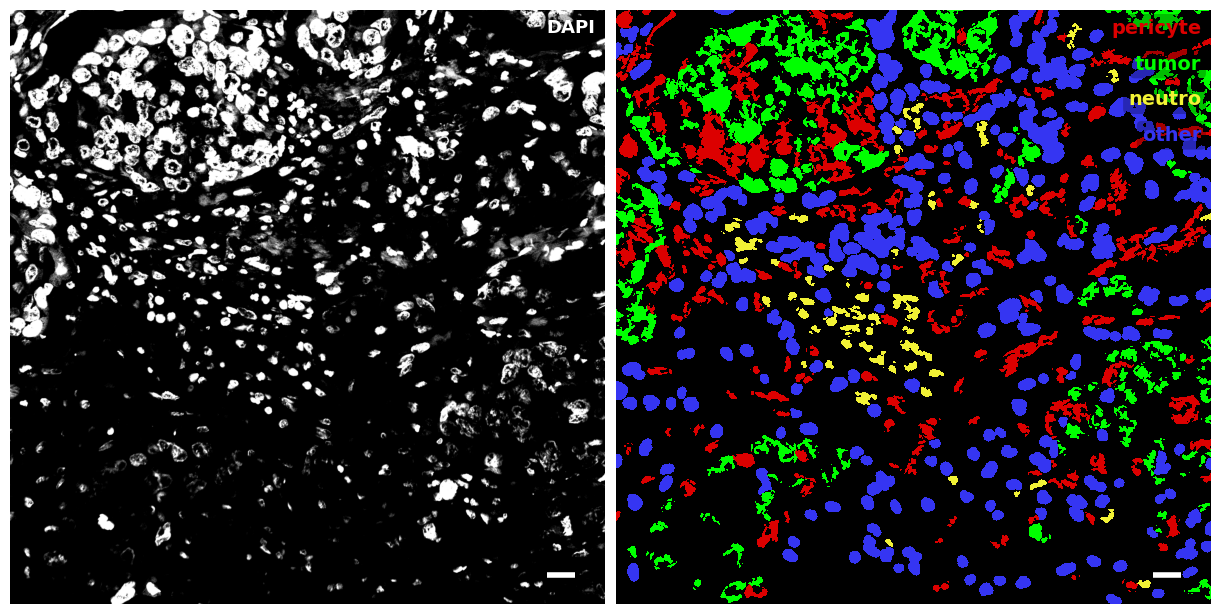

[saved] celltypes_panel.svg
[saved] celltypes_panel.tiff


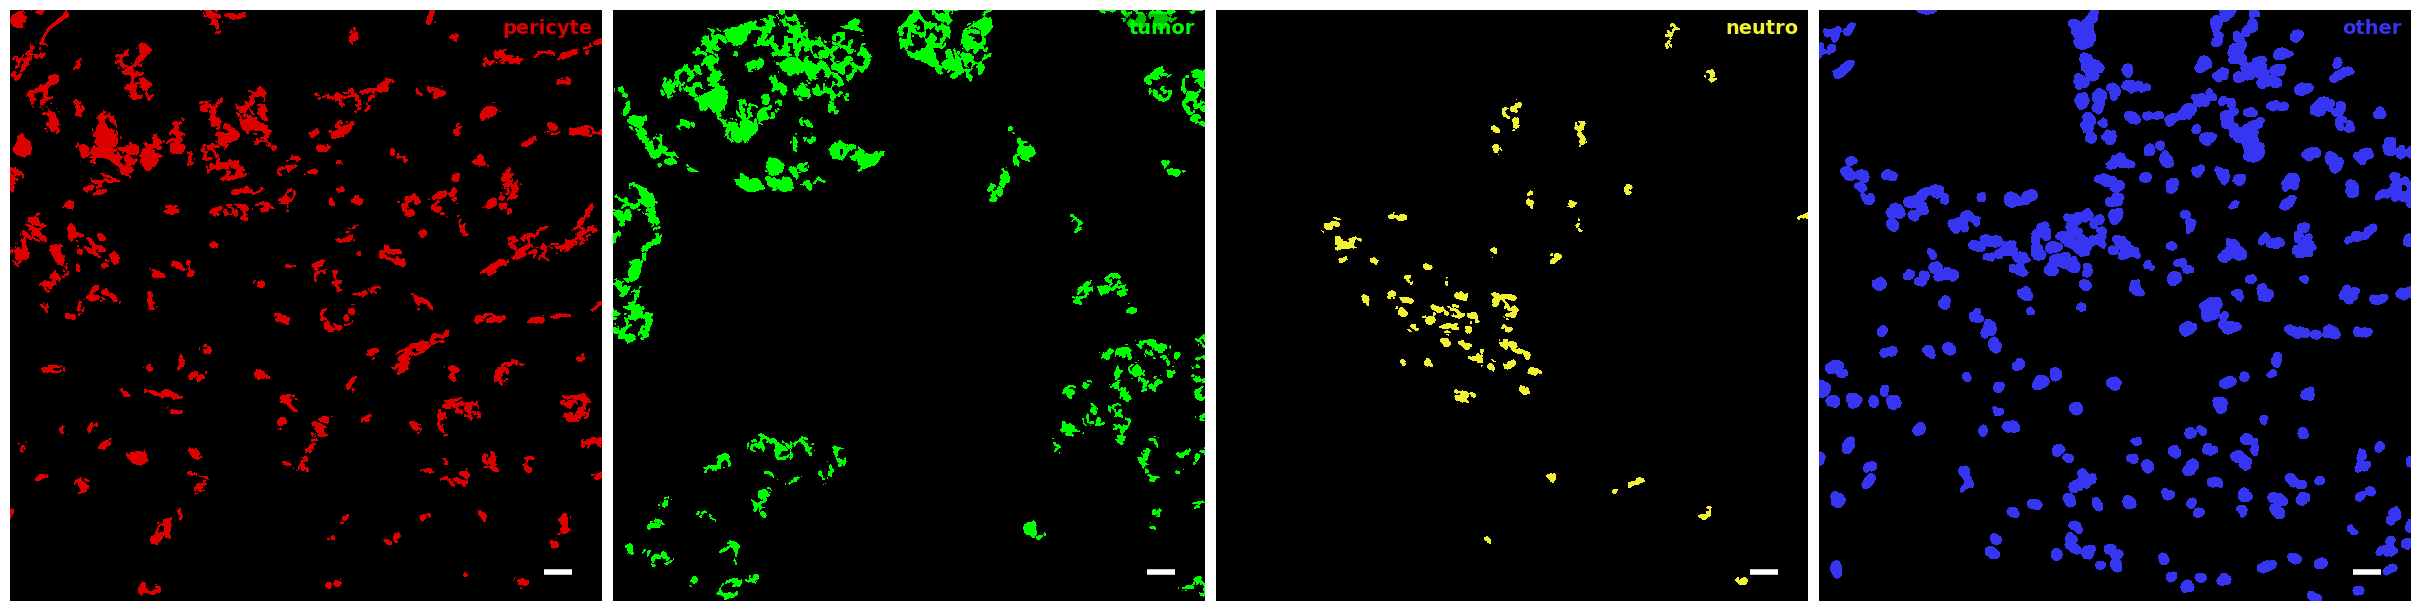

[saved] celltypes_split_panels.svg
[saved] celltypes_split_panels.tiff


In [33]:
# ===========================================================
# Cell 4B — ASSIGN cell types + SAVE mask + publication plots (ROBUST)
# - Uses CELLTYPE_CFG from 4A (simple logic + expr supported)
# - Computes marker positivity per nucleus via buffer-zone voting assignment
# - Builds pixel-level celltype_mask (1..K) and saves:
#     SAVE_DIR / "celltypes_mask_uint16.tiff"
# - Also saves:
#     SAVE_DIR / "cells_summary.csv"
#     SAVE_DIR / "celltype_counts.csv"
# - Generates publication-style plots:
#     SAVE_DIR / "celltypes_panel.svg/.tiff"
#     SAVE_DIR / "celltypes_split_panels.svg/.tiff"
# ===========================================================

import os, re, json
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

from scipy import ndimage as ndi
from skimage import filters, morphology, segmentation, measure, feature

from joblib import Parallel, delayed

# ---------------------------
# 0) Prereqs / config
# ---------------------------
if "CFG" not in globals() or not CFG:
    raise RuntimeError("CFG is empty. Run Cell 2 and click 'Save CONFIG' first.")
if "CELLTYPE_CFG" not in globals() or not CELLTYPE_CFG:
    raise RuntimeError("CELLTYPE_CFG is empty. Run Cell 4A and click 'Save cell types' first.")

FOLDER   = Path(CFG["FOLDER"])
SAVE_DIR = Path(CFG["SAVE_DIR"]); SAVE_DIR.mkdir(parents=True, exist_ok=True)
PIXEL_SIZE_UM = CFG.get("PIXEL_SIZE_UM", None)
IMAGE_ID = CFG.get("IMAGE_ID", "FieldA")
CHANNELS_CFG = CFG.get("CHANNELS", [])  # list of {file, channel, color_hex}

def _valid_pixel_size(ps):
    try:
        return ps is not None and len(ps) == 2 and float(ps[0]) > 0 and float(ps[1]) > 0
    except Exception:
        return False

if not _valid_pixel_size(PIXEL_SIZE_UM):
    raise RuntimeError("PIXEL_SIZE_UM missing/invalid. Please enter x/y µm and px in Cell 2 and Save CONFIG.")

px_um_x, px_um_y = float(PIXEL_SIZE_UM[0]), float(PIXEL_SIZE_UM[1])
px_area_um2 = px_um_x * px_um_y

# Threading: reuse env from Cell 1 if set; otherwise use cpu-1
cpu = os.cpu_count() or 1
TARGET_THREADS = int(os.environ.get("OMP_NUM_THREADS", max(1, cpu - 1)))
TARGET_THREADS = max(1, TARGET_THREADS)
NUMBA_THREADS = min(TARGET_THREADS, 24)

print("[info] SAVE_DIR =", SAVE_DIR)
print("[info] Threads:", TARGET_THREADS, "(numba max:", NUMBA_THREADS, ")")

# ---------------------------
# 1) Helpers: loading labels and channel images
# ---------------------------
def _load_any_tiff(path: Path):
    try:
        import tifffile
        return tifffile.imread(str(path))
    except Exception:
        import imageio.v2 as imageio
        return imageio.imread(str(path))

def ensure_labels_available():
    global labels
    if "labels" in globals() and isinstance(labels, np.ndarray):
        return
    p = SAVE_DIR / "nuclei_labels_uint16.tiff"
    if not p.exists():
        raise RuntimeError("Missing nuclei labels. Run nuclei segmentation first to create nuclei_labels_uint16.tiff")
    labels = _load_any_tiff(p).astype(np.int32)
    print("[info] loaded labels:", p.name, " shape=", labels.shape, " max=", int(labels.max()))

ensure_labels_available()
H, W = labels.shape
n_labels = int(labels.max())

# robust grid loader (in case df_pixels/to_image not in memory)
def _load_text_grid(path: Path, dtype=np.float32) -> np.ndarray:
    with open(path, "r", errors="ignore") as f:
        first = f.readline()
    if "\t" in first:
        sep = "\t"
    elif "," in first:
        sep = ","
    elif ";" in first:
        sep = ";"
    else:
        sep = r"\s+"
    df = pd.read_csv(path, header=None, sep=sep, engine="python" if sep == r"\s+" else "c")
    return df.to_numpy(dtype=dtype, copy=False)

# map channel name -> file path (from CFG)
CH2FILE = {c["channel"]: (FOLDER / c["file"]) for c in CHANNELS_CFG}
CH2HEX  = {c["channel"]: c.get("color_hex", "#ffffff") for c in CHANNELS_CFG}
CH_NAMES = list(CH2FILE.keys())

def _guess_nuclear_channel(chs):
    if not chs:
        return None
    upper = {c.upper(): c for c in chs}
    for k in ["DAPI", "HOECHST", "NUCLEUS", "NUCLEAR"]:
        if k in upper:
            return upper[k]
    for c in chs:
        cu = c.upper()
        if ("DAPI" in cu) or ("HOECHST" in cu) or ("NUC" in cu):
            return c
    return None

NUC_CHANNEL = _guess_nuclear_channel(CH_NAMES)

def get_channel_image(channel_name: str) -> np.ndarray:
    """
    Try to use existing to_image(df_pixels, shapes, ...) if available; else load from CSV/TXT directly.
    """
    if "to_image" in globals() and "df_pixels" in globals() and "shapes" in globals():
        try:
            return to_image(df_pixels, shapes, IMAGE_ID, channel_name).astype(np.float32)
        except Exception:
            pass
    p = CH2FILE.get(channel_name, None)
    if p is None or (not p.exists()):
        raise FileNotFoundError(f"Channel {channel_name!r} file not found in CFG/Folder.")
    return _load_text_grid(p).astype(np.float32, copy=False)

print("[info] Nuclear imaging channel detected:", NUC_CHANNEL)

# ---------------------------
# 2) Marker assignment geometry (Voronoi band + buffer zone)
# ---------------------------
def um_to_px_iso(v_um: float) -> int:
    s = np.sqrt(max(1e-12, px_um_x * px_um_y))
    return max(1, int(round(float(v_um) / s)))

R_VORONOI_UM   = 3.0
R_BUFFER_UM    = 2.0
R_VOTE_UM      = 3.0
TOPHAT_R_UM    = 1.0
GAUSS_SIGMA_UM = 0.5
THRESH_MODE    = "global_otsu"
MIN_POS_PIX    = 5

R_VORONOI_PX = um_to_px_iso(R_VORONOI_UM)
R_BUFFER_PX  = um_to_px_iso(R_BUFFER_UM)
R_VOTE_PX    = um_to_px_iso(R_VOTE_UM)
TOPHAT_PX    = um_to_px_iso(TOPHAT_R_UM)
GAUSS_SIGMA  = max(0.1, GAUSS_SIGMA_UM / max(1e-12, np.sqrt(px_um_x*px_um_y)))

outside = (labels == 0)
dist_outside, idxs = ndi.distance_transform_edt(outside, return_indices=True)
iy, ix = idxs
nearest_label_map = labels[iy, ix]
voronoi_band = outside & (dist_outside <= R_VORONOI_PX)

lab2 = segmentation.expand_labels(labels, distance=R_BUFFER_PX)
boundaries_thick = segmentation.find_boundaries(lab2, mode="thick")
buffer_zone = morphology.binary_dilation(boundaries_thick, morphology.disk(max(1, R_BUFFER_PX//2)))
buffer_zone &= voronoi_band

owner_map = labels.copy()
owner_map[voronoi_band] = nearest_label_map[voronoi_band]

def disk_offsets(radius: int):
    yy, xx = np.mgrid[-radius:radius+1, -radius:radius+1]
    m = (yy*yy + xx*xx) <= radius*radius
    return yy[m].astype(np.int32), xx[m].astype(np.int32)

vote_dys, vote_dxs = disk_offsets(R_VOTE_PX)
cand_dys, cand_dxs = disk_offsets(R_BUFFER_PX)

# ---------------------------
# 3) Numba buffer-zone voting (optional)
# ---------------------------
try:
    from numba import njit, prange, set_num_threads, get_num_threads
    try:
        set_num_threads(NUMBA_THREADS)
    except Exception:
        pass
    NUMBA_OK = True
    print(f"[numba] OK threads={get_num_threads()} layer={os.environ.get('NUMBA_THREADING_LAYER','default')}")
except Exception as e:
    NUMBA_OK = False
    print("[numba] not available -> pure python voting:", str(e))

if NUMBA_OK:
    @njit(parallel=True, fastmath=True)
    def _resolve_buffer_pixels(buf_ys, buf_xs, img_norm, owner_map, lab2, nearest_label_map,
                               vote_dys, vote_dxs, cand_dys, cand_dxs, H, W):
        MAX_CANDS = 8
        out = np.zeros(buf_ys.shape[0], np.int32)
        for i in prange(buf_ys.shape[0]):
            y = buf_ys[i]; x = buf_xs[i]
            cand_labels = np.zeros(MAX_CANDS, np.int32)
            n_cand = 0
            for k in range(cand_dys.shape[0]):
                yy = y + cand_dys[k]; xx = x + cand_dxs[k]
                if 0 <= yy < H and 0 <= xx < W:
                    lbl = lab2[yy, xx]
                    if lbl > 0:
                        seen = False
                        for j in range(n_cand):
                            if cand_labels[j] == lbl:
                                seen = True; break
                        if (not seen) and (n_cand < MAX_CANDS):
                            cand_labels[n_cand] = lbl
                            n_cand += 1
            if n_cand == 0:
                out[i] = nearest_label_map[y, x]
                continue
            best_lbl = 0
            best_vote = -1.0
            for j in range(n_cand):
                lbl = cand_labels[j]
                vote = 0.0
                for k in range(vote_dys.shape[0]):
                    yy = y + vote_dys[k]; xx = x + vote_dxs[k]
                    if 0 <= yy < H and 0 <= xx < W:
                        if owner_map[yy, xx] == lbl:
                            vote += img_norm[yy, xx]
                if vote > best_vote:
                    best_vote = vote
                    best_lbl = lbl
            if best_lbl == 0:
                best_lbl = nearest_label_map[y, x]
            out[i] = best_lbl
        return out
else:
    def _resolve_buffer_pixels(buf_ys, buf_xs, img_norm, owner_map, lab2, nearest_label_map,
                               vote_dys, vote_dxs, cand_dys, cand_dxs, H, W):
        out = np.zeros(buf_ys.shape[0], np.int32)
        for i, (y, x) in enumerate(zip(buf_ys, buf_xs)):
            cand = set()
            for dy, dx in zip(cand_dys, cand_dxs):
                yy, xx = y+dy, x+dx
                if 0 <= yy < H and 0 <= xx < W:
                    lbl = lab2[yy, xx]
                    if lbl > 0:
                        cand.add(int(lbl))
            if not cand:
                out[i] = int(nearest_label_map[y, x]); continue
            best_lbl, best_vote = 0, -1.0
            for lbl in cand:
                vote = 0.0
                for dy, dx in zip(vote_dys, vote_dxs):
                    yy, xx = y+dy, x+dx
                    if 0 <= yy < H and 0 <= xx < W and owner_map[yy, xx] == lbl:
                        vote += float(img_norm[yy, xx])
                if vote > best_vote:
                    best_vote, best_lbl = vote, lbl
            out[i] = best_lbl or int(nearest_label_map[y, x])
        return out

# ---------------------------
# 4) Marker preprocessing + assignment
# ---------------------------
def preprocess_marker(img):
    img = img.astype(np.float32, copy=False)
    lo, hi = np.nanpercentile(img, [1, 99.8])
    norm = np.clip((img - lo) / max(hi - lo, 1e-6), 0, 1)
    if TOPHAT_PX > 0:
        norm = morphology.white_tophat(norm, footprint=morphology.disk(TOPHAT_PX))
    if GAUSS_SIGMA > 0:
        norm = filters.gaussian(norm, sigma=GAUSS_SIGMA, preserve_range=True)
    return norm

def marker_positive_mask(img_norm):
    if THRESH_MODE == "global_otsu":
        thr = filters.threshold_otsu(img_norm)
    elif THRESH_MODE == "yen":
        thr = filters.threshold_yen(img_norm)
    elif THRESH_MODE == "triangle":
        thr = filters.threshold_triangle(img_norm)
    else:
        thr = filters.threshold_otsu(img_norm)
    pos = img_norm > thr
    pos = morphology.remove_small_objects(pos, min_size=9)
    return pos, float(thr)

def safe_key(name: str) -> str:
    s = re.sub(r"[^0-9A-Za-z]+", "_", str(name)).strip("_")
    return s.upper() if s else "MARKER"

NUC_KEY = "NUCLEUS"

def marker_name_to_key(m: str) -> str:
    mu = (m or "").strip().upper()
    if mu in {"NUCLEUS", "NUCLEAR", "NUC"}:
        return NUC_KEY
    if "DAPI" in mu or "HOECHST" in mu:
        return NUC_KEY
    return safe_key(m)

# channels to assign (exclude nuclear imaging channel)
ASSIGN_CHANNELS = [ch for ch in CH_NAMES if (NUC_CHANNEL is None or ch != NUC_CHANNEL)]

assign_maps = {}    # marker_key -> uint16 map
df_stats_list = []  # per-marker per-label stats

def assign_marker_fast(img, marker_display_name):
    marker_key = marker_name_to_key(marker_display_name)
    if marker_key == NUC_KEY:
        raise ValueError("Do not run marker assignment for nucleus (built-in).")

    img_norm = preprocess_marker(img)
    pos_mask, thr = marker_positive_mask(img_norm)
    print(f"[{marker_display_name}] thr={thr:.4f} pos_pix={int(pos_mask.sum()):,}")

    assign_map = np.zeros_like(labels, dtype=np.uint16)

    # inside nuclei
    inside_mask = (labels > 0) & pos_mask
    assign_map[inside_mask] = labels[inside_mask].astype(np.uint16)

    # voronoi band (non-buffer)
    band_mask = pos_mask & voronoi_band
    nonbuf_mask = band_mask & (~buffer_zone)
    assign_map[nonbuf_mask] = nearest_label_map[nonbuf_mask].astype(np.uint16)

    # buffer zone voting
    by, bx = np.nonzero(pos_mask & buffer_zone)
    if by.size:
        picked = _resolve_buffer_pixels(by.astype(np.int32), bx.astype(np.int32),
                                        img_norm, owner_map, lab2, nearest_label_map,
                                        vote_dys, vote_dxs, cand_dys, cand_dxs, H, W)
        assign_map[by, bx] = picked.astype(np.uint16)

    # per-label stats
    flat_lab = assign_map.ravel().astype(np.int32)
    flat_val = img_norm.ravel()
    max_lab = int(flat_lab.max()) if flat_lab.size else 0
    pix_counts = np.bincount(flat_lab, minlength=max_lab+1).astype(np.int64)
    val_sums   = np.bincount(flat_lab, weights=flat_val, minlength=max_lab+1)

    dfm = pd.DataFrame({
        "label": np.arange(max_lab+1, dtype=int),
        f"{marker_key}_pos_pix": pix_counts,
        f"{marker_key}_sum_intensity": val_sums
    })
    dfm = dfm[dfm["label"] > 0].reset_index(drop=True)

    # save assign map (optional but useful)
    try:
        import tifffile
        tifffile.imwrite(str(SAVE_DIR / f"marker_assign_{marker_key}_uint16.tiff"), assign_map.astype(np.uint16))
    except Exception:
        pass

    return marker_key, assign_map, dfm

for ch in ASSIGN_CHANNELS:
    mk = marker_name_to_key(ch)
    if mk == NUC_KEY:
        continue
    img = get_channel_image(ch)
    key, amap, dfm = assign_marker_fast(img, ch)
    assign_maps[key] = amap
    df_stats_list.append(dfm)

# ---------------------------
# 5) Build df_cells (per nucleus) + positivity
# ---------------------------
def _build_df_props_from_current_labels(labels):
    intensity_image = None
    if NUC_CHANNEL is not None:
        try:
            intensity_image = get_channel_image(NUC_CHANNEL)
        except Exception:
            intensity_image = None

    base_props = ("label", "area", "perimeter", "eccentricity", "solidity", "centroid", "bbox")
    if intensity_image is not None:
        props = measure.regionprops_table(
            labels,
            intensity_image=intensity_image,
            properties=base_props + ("mean_intensity", "max_intensity")
        )
    else:
        props = measure.regionprops_table(
            labels,
            properties=base_props
        )

    out = pd.DataFrame(props)

    out.rename(columns={
        "centroid-0": "centroid_y_px", "centroid-1": "centroid_x_px",
        "bbox-0": "bbox_min_y_px", "bbox-1": "bbox_min_x_px",
        "bbox-2": "bbox_max_y_px", "bbox-3": "bbox_max_x_px",
    }, inplace=True)

    out["label"] = out["label"].astype(int)
    out["centroid_x_um"] = out["centroid_x_px"].to_numpy(float) * px_um_x
    out["centroid_y_um"] = out["centroid_y_px"].to_numpy(float) * px_um_y
    out["area_um2"] = out["area"].to_numpy(float) * px_area_um2
    out["perimeter_um"] = out["perimeter"].to_numpy(float) * np.sqrt(max(1e-12, px_um_x * px_um_y))

    return out.sort_values("label").reset_index(drop=True)

# Always rebuild from current labels.
# This avoids stale df_props after nuclei retuning / overwrite.
df_props = _build_df_props_from_current_labels(labels)
print(f"[info] rebuilt df_props from current labels: n={len(df_props)}")

df_cells = df_props.copy()
for dfm in df_stats_list:
    df_cells = df_cells.merge(dfm, on="label", how="left")
df_cells.fillna(0, inplace=True)

# built-in nucleus stats
nuc_area = np.bincount(labels.ravel().astype(np.int64), minlength=n_labels + 1).astype(np.int64)
lab_idx = df_cells["label"].to_numpy(np.int64)

if lab_idx.min() < 1 or lab_idx.max() > n_labels:
    raise RuntimeError(
        f"Label mismatch: df_cells has labels {lab_idx.min()}..{lab_idx.max()}, "
        f"but current labels max is {n_labels}."
    )

df_cells["NUCLEUS_pos_pix"] = nuc_area[lab_idx]
df_cells["NUCLEUS_pos"] = df_cells["NUCLEUS_pos_pix"] > 0

if "centroid_x_um" not in df_cells.columns:
    df_cells["centroid_x_um"] = df_cells["centroid_x_px"].to_numpy(float) * px_um_x
if "centroid_y_um" not in df_cells.columns:
    df_cells["centroid_y_um"] = df_cells["centroid_y_px"].to_numpy(float) * px_um_y

# marker positivity columns
marker_keys = sorted(assign_maps.keys())
for mk in marker_keys:
    df_cells[f"{mk}_pos"] = df_cells.get(f"{mk}_pos_pix", 0) >= MIN_POS_PIX

# ---------------------------
# 6) Cell type classification (CELLTYPE_CFG: simple + expr)
# ---------------------------
def is_pos(row, mk: str) -> bool:
    if mk == NUC_KEY:
        return bool(row.get("NUCLEUS_pos", False))
    col = f"{mk}_pos"
    return bool(row.get(col, False))

def match_simple(ct, row) -> bool:
    all_pos = [marker_name_to_key(m) for m in ct.get("all_pos", [])]
    all_neg = [marker_name_to_key(m) for m in ct.get("all_neg", [])]
    any_groups = [[marker_name_to_key(m) for m in grp] for grp in ct.get("any_pos_groups", [])]

    if not all(is_pos(row, mk) for mk in all_pos):
        return False
    if not all((not is_pos(row, mk)) for mk in all_neg):
        return False
    for grp in any_groups:
        if grp and (not any(is_pos(row, mk) for mk in grp)):
            return False
    return True

def _norm_expr(expr: str) -> str:
    e = (expr or "").strip()
    e = re.sub(r"\bAND\b", "and", e, flags=re.I)
    e = re.sub(r"\bOR\b",  "or",  e, flags=re.I)
    e = re.sub(r"\bNOT\b", "not", e, flags=re.I)
    return e

compiled_expr = []
for ct in CELLTYPE_CFG:
    if ct.get("mode") == "expr":
        expr = _norm_expr(ct.get("expr", ""))
        try:
            compiled_expr.append(compile(expr, "<celltype_expr>", "eval") if expr else None)
        except Exception as e:
            print(f"⚠️ Expr compile failed for '{ct['name']}': {e}")
            compiled_expr.append(None)
    else:
        compiled_expr.append(None)

# available keys for env
ENV_KEYS = [NUC_KEY] + marker_keys

def match_expr(ct_idx: int, row) -> bool:
    code = compiled_expr[ct_idx]
    if code is None:
        return False
    env = {k: is_pos(row, k) for k in ENV_KEYS}
    try:
        return bool(eval(code, {"__builtins__": {}}, env))
    except Exception:
        return False

K = len(CELLTYPE_CFG)
celltype_id = np.zeros(len(df_cells), dtype=np.uint16)
celltype_nm = np.array([""] * len(df_cells), dtype=object)

for i in range(len(df_cells)):
    r = df_cells.iloc[i]
    assigned = False
    for k, ct in enumerate(CELLTYPE_CFG, start=1):
        ok = False
        if ct.get("mode") == "simple":
            ok = match_simple(ct, r)
        else:
            ok = match_expr(k-1, r)
        if ok:
            celltype_id[i] = k
            celltype_nm[i] = ct["name"]
            assigned = True
            break
    if not assigned:
        celltype_id[i] = 1
        celltype_nm[i] = CELLTYPE_CFG[0]["name"]

df_cells["celltype_id"] = celltype_id.astype(int)
df_cells["celltype"] = celltype_nm

# ---------------------------
# 7) Build pixel-level celltype_mask and SAVE
# ---------------------------
celltype_id_by_label = np.zeros(n_labels + 1, dtype=np.uint16)
lab_ct = df_cells[["label","celltype_id"]].to_numpy()
celltype_id_by_label[lab_ct[:,0].astype(int)] = lab_ct[:,1].astype(np.uint16)

# decide which types have NON-nucleus positive requirements (for rim)
def type_has_non_nucleus(ct) -> bool:
    if ct.get("mode") == "simple":
        keys = []
        keys += [marker_name_to_key(m) for m in ct.get("all_pos", [])]
        for grp in ct.get("any_pos_groups", []):
            keys += [marker_name_to_key(m) for m in grp]
        keys = [k for k in keys if k != NUC_KEY]
        return len(keys) > 0
    else:
        expr = _norm_expr(ct.get("expr",""))
        toks = re.findall(r"\b[A-Za-z_][A-Za-z0-9_]*\b", expr)
        toks = [t for t in toks if t.lower() not in {"and","or","not","true","false"}]
        toks = [t for t in toks if t.upper() != NUC_KEY]
        return len(toks) > 0

type_has_marker = np.array([False] + [type_has_non_nucleus(ct) for ct in CELLTYPE_CFG], dtype=bool)  # 0 unused

slices_list = ndi.find_objects(labels)
MARGIN = int(max(R_VORONOI_PX, R_BUFFER_PX) + 2)
assign_map_list = list(assign_maps.values())

def _expand_slice(slc, margin, H, W):
    sy, sx = slc
    y0 = max(0, sy.start - margin); y1 = min(H, sy.stop + margin)
    x0 = max(0, sx.start - margin); x1 = min(W, sx.stop + margin)
    return (slice(y0,y1), slice(x0,x1))

def _support_for_label(lab: int):
    slc0 = slices_list[lab-1]
    if slc0 is None:
        return lab, None, None
    slc = _expand_slice(slc0, MARGIN, H, W)
    lbl_loc  = labels[slc]
    own_loc  = owner_map[slc]
    dist_loc = dist_outside[slc]

    ct = int(celltype_id_by_label[lab])

    support = (lbl_loc == lab)
    for amap in assign_map_list:
        support |= (amap[slc] == lab)

    if ct >= 1 and ct <= K and (not type_has_marker[ct]):
        support |= (own_loc == lab) & (dist_loc <= R_BUFFER_PX)

    support = ndi.binary_fill_holes(support)
    return lab, ct, (slc, support)

results = Parallel(n_jobs=TARGET_THREADS, prefer="threads", batch_size=64)(
    delayed(_support_for_label)(lab) for lab in range(1, n_labels+1)
)

celltype_mask = np.zeros_like(labels, dtype=np.uint16)
for lab, ct, payload in results:
    if payload is None:
        continue
    slc, support = payload
    celltype_mask[slc][support] = np.uint16(ct)

# SAVE mask
try:
    import tifffile
    tifffile.imwrite(str(SAVE_DIR / "celltypes_mask_uint16.tiff"), celltype_mask.astype(np.uint16))
    print("[saved] celltypes_mask_uint16.tiff")
except Exception as e:
    print("⚠️ Could not save mask TIFF:", e)

# SAVE tables
df_cells.to_csv(SAVE_DIR / "cells_summary.csv", index=False)
counts = df_cells["celltype"].value_counts().rename_axis("celltype").reset_index(name="count")
counts.to_csv(SAVE_DIR / "celltype_counts.csv", index=False)
print("[saved] cells_summary.csv")
print("[saved] celltype_counts.csv")
print(counts)

# ---------------------------
# 8) Publication-style plots (no axes/border, colored labels, 20µm scalebar)
# ---------------------------
def _axis_off(ax):
    ax.set_axis_off()
    ax.set_frame_on(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

def _add_scalebar_20um(ax, arr_shape, px_um_x, bar_um=20.0, color="white", lw=4, pad_frac=0.05):
    # robust: accept shapes like (H,W) or (H,W,C)
    h = int(arr_shape[0]); w = int(arr_shape[1])
    if px_um_x is None or float(px_um_x) <= 0:
        return
    bar_px = int(round(float(bar_um) / float(px_um_x)))
    pad_x = int(round(pad_frac * w))
    pad_y = int(round(pad_frac * h))
    x_end = w - pad_x
    x_start = max(pad_x, x_end - bar_px)
    y = h - pad_y
    ax.plot([x_start, x_end], [y, y], color=color, lw=lw, solid_capstyle="butt")

def _add_colored_type_text(ax, names, colors_hex, x=0.985, y0=0.985, fontsize=14):
    n = max(1, len(names))
    dy = min(0.06, 0.90 / n)
    fs = fontsize if n <= 6 else max(8, int(fontsize * 6 / n))
    y = y0
    for nm, hx in zip(names, colors_hex):
        ax.text(
            x, y, nm,
            transform=ax.transAxes, ha="right", va="top",
            fontsize=fs, fontweight="bold",
            color=hx,
            bbox=dict(boxstyle="round,pad=0.25", facecolor=(0,0,0,0.25), edgecolor="none")
        )
        y -= dy

ct_names = [ct["name"] for ct in CELLTYPE_CFG]
ct_hex   = [ct["color_hex"] for ct in CELLTYPE_CFG]
ct_rgb   = [(0,0,0)] + [mcolors.to_rgb(h) for h in ct_hex]
cmap_ct  = ListedColormap(ct_rgb)

# left panel: nuclear channel if available
nuc_norm = None
if NUC_CHANNEL is not None:
    try:
        nuc_img = get_channel_image(NUC_CHANNEL)
        p1, p99 = np.nanpercentile(nuc_img, [1, 99.8])
        nuc_norm = np.clip((nuc_img - p1) / (p99 - p1 + 1e-6), 0, 1)
    except Exception:
        nuc_norm = None

panel_svg  = SAVE_DIR / "celltypes_panel.svg"
panel_tiff = SAVE_DIR / "celltypes_panel.tiff"

if nuc_norm is None:
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(celltype_mask, cmap=cmap_ct, origin="upper", interpolation="nearest", vmin=0, vmax=K)
    _axis_off(ax)
    _add_scalebar_20um(ax, celltype_mask.shape, px_um_x, bar_um=20.0)
    _add_colored_type_text(ax, ct_names, ct_hex)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
else:
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 6))
    ax0.imshow(nuc_norm, cmap="gray", origin="upper")
    _axis_off(ax0)
    _add_scalebar_20um(ax0, nuc_norm.shape, px_um_x, bar_um=20.0)
    ax0.text(0.985, 0.985, NUC_CHANNEL, transform=ax0.transAxes,
             ha="right", va="top", fontsize=13, fontweight="bold", color="white",
             bbox=dict(boxstyle="round,pad=0.25", facecolor=(0,0,0,0.25), edgecolor="none"))

    ax1.imshow(celltype_mask, cmap=cmap_ct, origin="upper", interpolation="nearest", vmin=0, vmax=K)
    _axis_off(ax1)
    _add_scalebar_20um(ax1, celltype_mask.shape, px_um_x, bar_um=20.0)
    _add_colored_type_text(ax1, ct_names, ct_hex)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.02)

fig.savefig(panel_svg, dpi=600, bbox_inches="tight", pad_inches=0)
fig.savefig(panel_tiff, dpi=600, bbox_inches="tight", pad_inches=0)
plt.show(); plt.close(fig)
print("[saved]", panel_svg.name)
print("[saved]", panel_tiff.name)

# split panels
split_svg  = SAVE_DIR / "celltypes_split_panels.svg"
split_tiff = SAVE_DIR / "celltypes_split_panels.tiff"

fig2, axes2 = plt.subplots(1, K, figsize=(6*K, 6))
if K == 1:
    axes2 = [axes2]

for i in range(1, K+1):
    ax = axes2[i-1]
    mask_i = (celltype_mask == i).astype(np.uint8)
    cmap_i = ListedColormap([(0,0,0), mcolors.to_rgb(ct_hex[i-1])])
    ax.imshow(mask_i, cmap=cmap_i, origin="upper", interpolation="nearest", vmin=0, vmax=1)
    _axis_off(ax)
    _add_scalebar_20um(ax, mask_i.shape, px_um_x, bar_um=20.0)
    ax.text(0.985, 0.985, ct_names[i-1], transform=ax.transAxes,
            ha="right", va="top", fontsize=14, fontweight="bold", color=ct_hex[i-1],
            bbox=dict(boxstyle="round,pad=0.25", facecolor=(0,0,0,0.25), edgecolor="none"))

fig2.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.02)
fig2.savefig(split_svg, dpi=600, bbox_inches="tight", pad_inches=0)
fig2.savefig(split_tiff, dpi=600, bbox_inches="tight", pad_inches=0)
plt.show(); plt.close(fig2)
print("[saved]", split_svg.name)
print("[saved]", split_tiff.name)

In [35]:
# ===========================================================
# Region segmentation + boundary overlay (INTERACTIVE, MULTI-TYPE) — FAST/ROBUST
# - Select MULTIPLE cell types to define region(s)
# - Control boundary style: thickness, color, linestyle (incl solid)
# - Publication style plot: no axes/border, colored type labels top-right, 20µm scalebar
# - Saves:
#     <type>_region_mask_uint8.tiff  (per selected type)
#     celltypes_with_boundaries__<types>.{svg,tiff}
#     celltype_counts_by_region__<types>.csv
#     cell_region_assignments__<types>.csv
# ===========================================================

import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from skimage import morphology, measure
from skimage.measure import find_contours
from scipy import ndimage as ndi
import traceback

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except Exception as e:
    raise RuntimeError("ipywidgets is required for the interactive UI. Install: pip install ipywidgets") from e

# ---------- Resolve SAVE_DIR ----------
if "SAVE_DIR" not in globals():
    if "CFG" in globals() and CFG and "SAVE_DIR" in CFG:
        SAVE_DIR = Path(CFG["SAVE_DIR"])
    else:
        SAVE_DIR = Path("./outs")
SAVE_DIR = Path(SAVE_DIR); SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Ensure required objects exist ----------
if "CELLTYPE_CFG" not in globals() or not CELLTYPE_CFG:
    raise RuntimeError("CELLTYPE_CFG not found. Run Cell 4A and save cell types.")
if "df_cells" not in globals():
    raise RuntimeError("df_cells not found. Run the Cell 4B ASSIGNMENT cell first.")
if "labels" not in globals():
    # try to load nuclei labels
    p = SAVE_DIR / "nuclei_labels_uint16.tiff"
    if not p.exists():
        raise RuntimeError("labels not in memory and nuclei_labels_uint16.tiff not found. Run nuclei segmentation first.")
    try:
        import tifffile
        labels = tifffile.imread(str(p)).astype(np.int32)
        print("[info] loaded labels from:", p.name)
    except Exception as e:
        raise RuntimeError("Failed to load nuclei labels TIFF.") from e

# ---------- Ensure celltype_mask exists (load ONLY the correct mask file) ----------
def _load_tiff(path: Path):
    try:
        import tifffile
        return tifffile.imread(str(path))
    except Exception:
        import imageio.v2 as imageio
        return imageio.imread(str(path))

if "celltype_mask" not in globals():
    p = SAVE_DIR / "celltypes_mask_uint16.tiff"
    if not p.exists():
        raise RuntimeError(
            "celltype_mask not in memory and celltypes_mask_uint16.tiff not found.\n"
            "Please run the Cell 4B ASSIGNMENT cell first (it creates/saves this file)."
        )
    celltype_mask = _load_tiff(p).astype(np.uint16)
    print("[info] loaded celltype_mask from:", p.name, " shape=", celltype_mask.shape)

# sanity check: must be 2D label mask
if celltype_mask.ndim != 2:
    raise RuntimeError(
        f"celltype_mask must be a 2D label image, but got shape={celltype_mask.shape}.\n"
        "This usually happens if you accidentally loaded an RGB figure TIFF instead of the mask.\n"
        "Use SAVE_DIR/'celltypes_mask_uint16.tiff' produced by the 4B assignment step."
    )

H, W = celltype_mask.shape

req_cols = {"label", "celltype", "centroid_x_px", "centroid_y_px"}
if not req_cols.issubset(set(df_cells.columns)):
    raise RuntimeError(f"df_cells must contain columns: {req_cols}")

# ---------- Pixel size ----------
def _valid_pixel_size(ps):
    try:
        return ps is not None and len(ps) == 2 and float(ps[0]) > 0 and float(ps[1]) > 0
    except Exception:
        return False

if "PIXEL_SIZE_UM" in globals() and _valid_pixel_size(PIXEL_SIZE_UM):
    px_um_x, px_um_y = float(PIXEL_SIZE_UM[0]), float(PIXEL_SIZE_UM[1])
elif "CFG" in globals() and CFG and _valid_pixel_size(CFG.get("PIXEL_SIZE_UM", None)):
    px_um_x, px_um_y = float(CFG["PIXEL_SIZE_UM"][0]), float(CFG["PIXEL_SIZE_UM"][1])
else:
    px_um_x = px_um_y = 1.0
    print("⚠️ PIXEL_SIZE_UM missing/invalid; assuming 1.0 µm/px (um thresholds may be off).")

px_area_um2 = px_um_x * px_um_y

def um_to_px_iso(v_um: float) -> int:
    s = np.sqrt(max(1e-12, px_um_x * px_um_y))
    return max(1, int(round(float(v_um) / s)))

# ---------- Publication-style helpers ----------
def _axis_off(ax):
    ax.set_axis_off()
    ax.set_frame_on(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

def _add_scalebar_20um(ax, arr_shape, px_um_x, bar_um=20.0, color="white", lw=4, pad_frac=0.05):
    # robust for (H,W) only
    h, w = int(arr_shape[0]), int(arr_shape[1])
    if px_um_x is None or float(px_um_x) <= 0:
        return
    bar_px = int(round(float(bar_um) / float(px_um_x)))
    if bar_px <= 0:
        return
    pad_x = int(round(pad_frac * w))
    pad_y = int(round(pad_frac * h))
    x_end = w - pad_x
    x_start = max(pad_x, x_end - bar_px)
    y = h - pad_y
    ax.plot([x_start, x_end], [y, y], color=color, lw=lw, solid_capstyle="butt")

def _add_colored_type_text(ax, names, colors_hex, title=None, x=0.985, y0=0.985, fontsize=14):
    n = max(1, len(names))
    dy = min(0.06, 0.90 / n)
    fs = fontsize if n <= 6 else max(8, int(fontsize * 6 / n))
    y = y0
    if title:
        ax.text(
            x, y, title,
            transform=ax.transAxes, ha="right", va="top",
            fontsize=fs, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.25", facecolor=(0,0,0,0.30), edgecolor="none")
        )
        y -= dy
    for nm, hx in zip(names, colors_hex):
        ax.text(
            x, y, nm,
            transform=ax.transAxes, ha="right", va="top",
            fontsize=fs, fontweight="bold", color=hx,
            bbox=dict(boxstyle="round,pad=0.25", facecolor=(0,0,0,0.25), edgecolor="none")
        )
        y -= dy

def _safe_name(s: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "_", str(s)).strip("_") or "region"

# ---------- Cell type names/colors + colormap ----------
K = len(CELLTYPE_CFG)
ct_names = [ct["name"] for ct in CELLTYPE_CFG]
ct_hex   = [ct["color_hex"] for ct in CELLTYPE_CFG]
ct_rgb   = [(0,0,0)] + [mcolors.to_rgb(h) for h in ct_hex]
cmap_ct  = ListedColormap(ct_rgb)

name_to_id = {ct_names[i]: (i+1) for i in range(K)}  # mask uses 1..K

# ---------- Fast region mask builder ----------
def build_region_mask_for_type(type_name: str,
                               close_px: int,
                               dilate_px: int,
                               min_area_px: int,
                               min_cells: int):
    type_id = name_to_id[type_name]
    region = (celltype_mask == type_id)

    # Fast(er) closing/dilation for large radii if available
    if close_px > 0:
        if hasattr(morphology, "isotropic_closing"):
            region = morphology.isotropic_closing(region, radius=close_px)
        else:
            region = morphology.binary_closing(region, footprint=morphology.disk(close_px))

    region = ndi.binary_fill_holes(region)

    if min_area_px > 0:
        region = morphology.remove_small_objects(region, min_size=min_area_px)

    if dilate_px > 0:
        if hasattr(morphology, "isotropic_dilation"):
            region = morphology.isotropic_dilation(region, radius=dilate_px)
        else:
            region = morphology.binary_dilation(region, footprint=morphology.disk(dilate_px))

    lbl = measure.label(region, connectivity=2)
    if lbl.max() == 0:
        return np.zeros_like(region, dtype=bool)

    # centroid filtering (fast bincount)
    sub = df_cells[df_cells["celltype"].astype(str) == str(type_name)][["centroid_x_px","centroid_y_px"]]
    if len(sub) == 0:
        return np.zeros_like(region, dtype=bool)

    cy = np.clip(np.rint(sub["centroid_y_px"].to_numpy(float)).astype(int), 0, H-1)
    cx = np.clip(np.rint(sub["centroid_x_px"].to_numpy(float)).astype(int), 0, W-1)
    rid = lbl[cy, cx]
    rid = rid[rid > 0]
    if rid.size == 0:
        return np.zeros_like(region, dtype=bool)

    counts = np.bincount(rid, minlength=int(lbl.max())+1)
    keep_ids = np.where(counts >= int(min_cells))[0]
    keep_ids = keep_ids[keep_ids > 0]
    if keep_ids.size == 0:
        return np.zeros_like(region, dtype=bool)

    return np.isin(lbl, keep_ids)

# ============================================================
# Interactive UI
# ============================================================
type_sel = widgets.SelectMultiple(
    options=ct_names,
    value=(ct_names[0],) if ct_names else (),
    description="Types:",
    rows=min(10, max(4, len(ct_names)))
)

# Morphology controls (these often cause “no response” if too big)
close_um = widgets.FloatSlider(value=15.0, min=0.0, max=80.0, step=1.0, description="Close (µm):")
dilate_um = widgets.FloatSlider(value=10.0, min=0.0, max=80.0, step=1.0, description="Dilate (µm):")
min_area_um2 = widgets.FloatText(value=20000.0, description="Min area (µm²):")
min_cells = widgets.IntText(value=5, description="Min cells:")

# Contour downsample (for plotting speed only)
contour_ds = widgets.Dropdown(
    options=[("1× (full)", 1), ("2×", 2), ("4×", 4), ("8×", 8)],
    value=2,
    description="Contour ds:"
)

# Boundary style
linewidth = widgets.FloatSlider(value=2.0, min=0.5, max=10.0, step=0.5, description="Width:")
linestyle = widgets.Dropdown(
    options=[("Solid", "-"), ("Dashed", "--"), ("Dash-dot", "-."), ("Dotted", ":")],
    value="--",
    description="Style:"
)
boundary_color = widgets.ColorPicker(concise=True, value="#a1d99b", description="Color:")
use_type_colors = widgets.Checkbox(value=False, description="Use each type's color for boundary")

run_btn = widgets.Button(description="Run boundaries + counts", button_style="success")
status = widgets.HTML("")
ui_out = widgets.Output()

def _run(_=None):
    run_btn.disabled = True
    status.value = "<b>Running...</b>"
    with ui_out:
        clear_output()
        try:
            selected_types = list(type_sel.value)
            if not selected_types:
                print("❌ Please select at least one cell type.")
                return

            print("[info] Selected types:", selected_types)

            # precompute params
            CLOSE_R_PX  = um_to_px_iso(float(close_um.value))
            DILATE_R_PX = um_to_px_iso(float(dilate_um.value))
            MIN_AREA_PX = int(round(float(min_area_um2.value) / max(1e-12, px_area_um2)))
            MIN_CELLS   = int(min_cells.value)

            print(f"[params] close={close_um.value}µm({CLOSE_R_PX}px)  dilate={dilate_um.value}µm({DILATE_R_PX}px)  "
                  f"min_area={min_area_um2.value}µm²({MIN_AREA_PX}px)  min_cells={MIN_CELLS}")

            # build centroid arrays once for later region assignment counts
            df_base = df_cells[["label", "celltype", "centroid_x_px", "centroid_y_px"]].copy()
            cy_all = np.clip(np.rint(df_base["centroid_y_px"].to_numpy(float)).astype(int), 0, H-1)
            cx_all = np.clip(np.rint(df_base["centroid_x_px"].to_numpy(float)).astype(int), 0, W-1)

            # ---- build masks
            status.value = "<b>Building region masks...</b>"
            masks = {}
            for tname in selected_types:
                print(f"  - building mask for {tname} ...")
                m = build_region_mask_for_type(tname, CLOSE_R_PX, DILATE_R_PX, MIN_AREA_PX, MIN_CELLS)
                masks[tname] = m

                # save mask
                try:
                    import tifffile
                    base = _safe_name(tname)
                    tif_reg = SAVE_DIR / f"{base}_region_mask_uint8.tiff"
                    tifffile.imwrite(str(tif_reg), m.astype(np.uint8))
                    print(f"    [saved] {tif_reg.name}")
                except Exception as e:
                    print(f"    ⚠️ could not save mask for {tname}: {e}")

            # ---- plot overlay
            status.value = "<b>Plotting boundaries...</b>"
            fig, ax = plt.subplots(1, 1, figsize=(8.5, 8))
            ax.imshow(celltype_mask, cmap=cmap_ct, origin="upper", interpolation="nearest", vmin=0, vmax=K)
            _axis_off(ax)

            lw = float(linewidth.value)
            ls = str(linestyle.value)
            col_user = str(boundary_color.value)
            ds = int(contour_ds.value)

            for tname in selected_types:
                m = masks[tname]
                if not np.any(m):
                    print(f"  - {tname}: mask empty (skipping contours)")
                    continue

                # Downsample ONLY for contour extraction speed
                if ds > 1:
                    m_ds = m[::ds, ::ds]
                    cnts = find_contours(m_ds.astype(float), 0.5)
                else:
                    cnts = find_contours(m.astype(float), 0.5)

                c_line = (CELLTYPE_CFG[name_to_id[tname]-1]["color_hex"] if use_type_colors.value else col_user)

                for cnt in cnts:
                    # cnt is (row=y, col=x). If downsampled, scale back.
                    x = cnt[:, 1] * ds
                    y = cnt[:, 0] * ds
                    ax.plot(x, y, ls, color=c_line, linewidth=lw, label="_nolegend_")

            title = "Boundaries: " + ", ".join(selected_types)
            _add_colored_type_text(ax, ct_names, ct_hex, title=title, fontsize=14)
            _add_scalebar_20um(ax, celltype_mask.shape, px_um_x, bar_um=20.0, color="white", lw=4, pad_frac=0.05)

            fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

            base_all = _safe_name("__".join(selected_types))
            out_svg  = SAVE_DIR / f"celltypes_with_boundaries__{base_all}.svg"
            out_tiff = SAVE_DIR / f"celltypes_with_boundaries__{base_all}.tiff"
            fig.savefig(out_svg, dpi=600, bbox_inches="tight", pad_inches=0)
            fig.savefig(out_tiff, dpi=600, bbox_inches="tight", pad_inches=0)
            plt.show()
            plt.close(fig)

            print(f"[saved] {out_svg.name}")
            print(f"[saved] {out_tiff.name}")

            # ---- counts by region
            status.value = "<b>Counting cells in regions...</b>"
            long_rows = []
            for tname in selected_types:
                m = masks[tname]
                inside = m[cy_all, cx_all] if np.any(m) else np.zeros_like(cy_all, dtype=bool)
                tmp = df_base.copy()
                tmp["boundary_type"] = tname
                tmp["region"] = np.where(inside, f"{tname}_region", "adjacent_region")
                long_rows.append(tmp)

            df_assign = pd.concat(long_rows, ignore_index=True)

            counts_by_region = (df_assign
                                .groupby(["boundary_type", "region", "celltype"])
                                .size()
                                .rename("count")
                                .reset_index()
                                .sort_values(["boundary_type", "region", "celltype"])
                                .reset_index(drop=True))

            print("\n[Cell-type counts by region]\n", counts_by_region)

            counts_csv = SAVE_DIR / f"celltype_counts_by_region__{base_all}.csv"
            assign_csv = SAVE_DIR / f"cell_region_assignments__{base_all}.csv"
            counts_by_region.to_csv(counts_csv, index=False)
            df_assign.to_csv(assign_csv, index=False)

            print(f"[saved] {counts_csv.name}")
            print(f"[saved] {assign_csv.name}")

            status.value = "<b>Done ✅</b>"

        except Exception:
            status.value = "<b style='color:#c00'>Error ❌ (see below)</b>"
            print(traceback.format_exc())
        finally:
            run_btn.disabled = False

run_btn.on_click(_run)

display(widgets.VBox([
    widgets.HTML("<h3>Boundary / Region segmentation (multi cell-type)</h3>"),
    widgets.HTML("<i>If it feels slow, reduce Close/Dilate or increase Contour ds (2×/4×/8×).</i>"),
    widgets.HBox([type_sel]),
    widgets.HBox([close_um, dilate_um]),
    widgets.HBox([min_area_um2, min_cells, contour_ds]),
    widgets.HBox([linewidth, linestyle, boundary_color]),
    widgets.HBox([use_type_colors, run_btn]),
    status,
    ui_out
]))

In [34]:
# ===========================================================
# Nearest-neighbor distances (interactive) — UPDATED
# Updates requested:
# - If >=2 query cell types: compute paired t-tests and annotate p-values on plot
#   * If 2 query types: paired t-test between them
#   * If >2 query types: paired t-tests vs the FIRST query type as reference
# - Draw lines connecting paired observations (same target cell across query types)
# - Export CSV includes target_label (pairing key) and query_label
# ===========================================================

import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except Exception as e:
    raise RuntimeError("ipywidgets is required for the interactive UI. Install: pip install ipywidgets") from e

from scipy.spatial import cKDTree
from scipy.stats import ttest_rel

# ---------- prerequisites ----------
if "df_cells" not in globals():
    raise RuntimeError("df_cells not found. Run Cell 4B first.")
if "CELLTYPE_CFG" not in globals() or not CELLTYPE_CFG:
    raise RuntimeError("CELLTYPE_CFG not found. Run Cell 4A and save cell types.")

# SAVE_DIR + pixel size
if "SAVE_DIR" not in globals():
    if "CFG" in globals() and CFG and "SAVE_DIR" in CFG:
        SAVE_DIR = Path(CFG["SAVE_DIR"])
    else:
        SAVE_DIR = Path("./outs")
SAVE_DIR = Path(SAVE_DIR); SAVE_DIR.mkdir(parents=True, exist_ok=True)

def _valid_pixel_size(ps):
    try:
        return ps is not None and len(ps) == 2 and float(ps[0]) > 0 and float(ps[1]) > 0
    except Exception:
        return False

if "PIXEL_SIZE_UM" in globals() and _valid_pixel_size(PIXEL_SIZE_UM):
    px_um_x, px_um_y = float(PIXEL_SIZE_UM[0]), float(PIXEL_SIZE_UM[1])
elif "CFG" in globals() and CFG and _valid_pixel_size(CFG.get("PIXEL_SIZE_UM", None)):
    px_um_x, px_um_y = float(CFG["PIXEL_SIZE_UM"][0]), float(CFG["PIXEL_SIZE_UM"][1])
else:
    raise RuntimeError("PIXEL_SIZE_UM is missing/invalid — needed to convert distances to µm.")

need_cols = {"label", "celltype", "centroid_x_px", "centroid_y_px"}
if not need_cols.issubset(df_cells.columns):
    raise RuntimeError(f"df_cells must contain columns: {need_cols}")

# available cell types
ct_names = [ct["name"] for ct in CELLTYPE_CFG]
present = sorted(set(df_cells["celltype"].astype(str)))
ct_names = [c for c in ct_names if c in present] or present

# ---------- helpers ----------
def _safe_name(s: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "_", str(s)).strip("_") or "dist"

def _nearest_pairs(df, target_type: str, query_type: str):
    """
    Per target cell, find nearest query cell (centroid-to-centroid, in µm).
    Returns:
      target_label, query_label, dist_um, dx_um, dy_um + coords
    """
    tdf = df[df["celltype"].astype(str) == str(target_type)].copy()
    qdf = df[df["celltype"].astype(str) == str(query_type)].copy()

    if len(tdf) == 0:
        raise ValueError(f"No cells found for target_type={target_type!r}")
    if len(qdf) == 0:
        raise ValueError(f"No cells found for query_type={query_type!r}")

    # centroids -> µm
    tx = tdf["centroid_x_px"].to_numpy(float) * px_um_x
    ty = tdf["centroid_y_px"].to_numpy(float) * px_um_y
    qx = qdf["centroid_x_px"].to_numpy(float) * px_um_x
    qy = qdf["centroid_y_px"].to_numpy(float) * px_um_y

    t_xy = np.column_stack([tx, ty])
    q_xy = np.column_stack([qx, qy])

    tree = cKDTree(q_xy)
    dist, idx = tree.query(t_xy, k=1, workers=-1)

    q_match = qdf.iloc[idx].reset_index(drop=True)
    out = pd.DataFrame({
        "target_type": target_type,
        "query_type": query_type,
        "target_label": tdf["label"].to_numpy(int),
        "query_label":  q_match["label"].to_numpy(int),
        "target_x_um":  tx,
        "target_y_um":  ty,
        "query_x_um":   q_match["centroid_x_px"].to_numpy(float) * px_um_x,
        "query_y_um":   q_match["centroid_y_px"].to_numpy(float) * px_um_y,
        "dist_um":      dist.astype(float),
    })
    out["dx_um"] = out["query_x_um"] - out["target_x_um"]
    out["dy_um"] = out["query_y_um"] - out["target_y_um"]
    return out

def _paired_ttests(df_long, qtypes):
    """
    Returns a DataFrame of paired t-tests.
    If len(qtypes)==2: compare qtypes[0] vs qtypes[1]
    If len(qtypes)>2: compare each qtypes[i] vs qtypes[0]
    """
    wide = df_long.pivot(index="target_label", columns="query_type", values="dist_um").reindex(columns=qtypes)
    comps = []
    if len(qtypes) == 2:
        comps = [(0, 1)]
    elif len(qtypes) > 2:
        comps = [(0, i) for i in range(1, len(qtypes))]

    rows = []
    for a, b in comps:
        qa, qb = qtypes[a], qtypes[b]
        x = wide[qa].to_numpy(float)
        y = wide[qb].to_numpy(float)
        m = np.isfinite(x) & np.isfinite(y)
        n = int(m.sum())
        if n < 2:
            p = np.nan
            t = np.nan
        else:
            t, p = ttest_rel(x[m], y[m], nan_policy="omit")
        rows.append({"ref": qa, "cmp": qb, "n_pairs": n, "t": t, "p": p})
    return pd.DataFrame(rows), wide

def _format_p(p):
    if not np.isfinite(p):
        return "p=NA"
    if p < 1e-4:
        return f"p={p:.1e}"
    return f"p={p:.4f}"

def _add_bracket(ax, x1, x2, y, h, text, fontsize=11):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color="black")
    ax.text((x1+x2)/2.0, y+h, text, ha="center", va="bottom", fontsize=fontsize)

def _plot_box_scatter(df_long, target_type, save_path=None, title=None):
    """
    Boxplot per query_type + jitter scatter + paired connecting lines + p-values.
    Points: (target_label, query_label) pairs.
    Lines: connect same target_label across query types.
    """
    qtypes = list(dict.fromkeys(df_long["query_type"].tolist()))
    data = [df_long.loc[df_long["query_type"] == q, "dist_um"].to_numpy(float) for q in qtypes]

    fig, ax = plt.subplots(figsize=(1.7 * max(3, len(qtypes)), 5))

    # Boxplot
    ax.boxplot(data, labels=qtypes, showfliers=False)

    # Scatter + paired lines
    # Make wide matrix for consistent pairing (one row per target_label)
    ttest_df, wide = _paired_ttests(df_long, qtypes)

    # Pair-lines (light gray)
    x_positions = np.arange(1, len(qtypes) + 1, dtype=float)
    for _, row in wide.iterrows():
        y = row.to_numpy(float)
        m = np.isfinite(y)
        if m.sum() >= 2:
            ax.plot(x_positions[m], y[m], linewidth=0.8, alpha=0.25)  # default line color

    # Scatter with jitter
    rng = np.random.default_rng(0)
    for i, q in enumerate(qtypes, start=1):
        y = df_long.loc[df_long["query_type"] == q, "dist_um"].to_numpy(float)
        x = i + rng.uniform(-0.12, 0.12, size=len(y))
        ax.scatter(x, y, s=18, alpha=0.8)

    ax.set_ylabel("Nearest distance (µm)")
    ax.set_xlabel("Query cell type")
    ax.set_title(title or f"Nearest neighbors to target: {target_type}")
    plt.xticks(rotation=30, ha="right")

    # P-value annotations (paired t-test)
    if len(qtypes) >= 2:
        # Determine y-range and bracket spacing
        all_y = np.concatenate([d[np.isfinite(d)] for d in data if len(d) > 0]) if data else np.array([0.0])
        y_max = float(np.nanmax(all_y)) if all_y.size else 1.0
        y_min = float(np.nanmin(all_y)) if all_y.size else 0.0
        span = max(1e-6, y_max - y_min)
        base_y = y_max + 0.06 * span
        step_h = 0.08 * span
        bracket_h = 0.02 * span

        # decide comparisons: if >2, compare vs first (ref)
        if len(qtypes) == 2:
            pairs = [(1, 2)]
        else:
            pairs = [(1, i+1) for i in range(1, len(qtypes))]  # vs first

        # add brackets
        for k, (x1, x2) in enumerate(pairs):
            row = ttest_df.iloc[k] if k < len(ttest_df) else None
            text = _format_p(row["p"]) if row is not None else "p=NA"
            y = base_y + k * step_h
            _add_bracket(ax, x1, x2, y, bracket_h, text)

        # add extra top margin
        ax.set_ylim(top=base_y + (len(pairs)+1) * step_h)

    plt.tight_layout()

    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(save_path), dpi=600, bbox_inches="tight")
        print(f"[saved] {save_path.name}")

    plt.show()
    plt.close(fig)

    return ttest_df  # return for reporting

# ---------- UI ----------
target_dd = widgets.Dropdown(options=ct_names, description="Target:")
query_sel = widgets.SelectMultiple(options=ct_names, description="Query:", rows=min(10, max(4, len(ct_names))))
run_btn = widgets.Button(description="Compute distances", button_style="success")
out = widgets.Output()

def _run(_=None):
    with out:
        clear_output()

        target = target_dd.value
        queries = list(query_sel.value)

        if not target:
            print("❌ Select a target cell type.")
            return
        if not queries:
            print("❌ Select at least one query cell type.")
            return

        print(f"[info] target={target!r}; queries={queries}")

        df = df_cells.copy()
        df["celltype"] = df["celltype"].astype(str)

        all_rows = []
        for q in queries:
            if q != target:
                all_rows.append(_nearest_pairs(df, target, q))
            else:
                # self-type nearest neighbor excluding itself (k=2)
                tdf = df[df["celltype"] == target].copy()
                if len(tdf) < 2:
                    raise ValueError(f"Need at least 2 cells of type {target!r} for self-type nearest neighbor.")
                tx = tdf["centroid_x_px"].to_numpy(float) * px_um_x
                ty = tdf["centroid_y_px"].to_numpy(float) * px_um_y
                t_xy = np.column_stack([tx, ty])
                tree = cKDTree(t_xy)
                dist, idx = tree.query(t_xy, k=2, workers=-1)  # [self, nearest-other]
                nn_dist = dist[:, 1]
                nn_idx = idx[:, 1]
                q_match = tdf.iloc[nn_idx].reset_index(drop=True)

                out_self = pd.DataFrame({
                    "target_type": target,
                    "query_type": target,
                    "target_label": tdf["label"].to_numpy(int),
                    "query_label":  q_match["label"].to_numpy(int),
                    "target_x_um":  tx,
                    "target_y_um":  ty,
                    "query_x_um":   q_match["centroid_x_px"].to_numpy(float) * px_um_x,
                    "query_y_um":   q_match["centroid_y_px"].to_numpy(float) * px_um_y,
                    "dist_um":      nn_dist.astype(float),
                })
                out_self["dx_um"] = out_self["query_x_um"] - out_self["target_x_um"]
                out_self["dy_um"] = out_self["query_y_um"] - out_self["target_y_um"]
                all_rows.append(out_self)

        df_long = pd.concat(all_rows, ignore_index=True)

        # Pairing key for later paired tests
        df_long["pair_id"] = df_long["target_label"].astype(str)

        # Export CSV
        base = _safe_name(f"nn_{target}__to__{'__'.join(queries)}")
        csv_path = SAVE_DIR / f"nearest_neighbor_distances__{base}.csv"
        df_long.to_csv(csv_path, index=False)
        print(f"[saved] {csv_path.name}")
        print(df_long.head(10))

        # Plot + p-values
        fig_path = SAVE_DIR / f"nearest_neighbor_distances__{base}.svg"
        ttest_df = _plot_box_scatter(
            df_long=df_long,
            target_type=target,
            save_path=fig_path,
            title=f"Nearest distances to target: {target}"
        )
        # Plot + p-values
        fig_path = SAVE_DIR / f"nearest_neighbor_distances__{base}.png"
        ttest_df = _plot_box_scatter(
            df_long=df_long,
            target_type=target,
            save_path=fig_path,
            title=f"Nearest distances to target: {target}"
        )


        # Report p-values (paired t-test)
        if len(set(df_long["query_type"])) >= 2:
            print("\n[paired t-tests]")
            if len(set(df_long["query_type"])) == 2:
                print("Comparison: query1 vs query2 (paired by target_label)")
            else:
                print("Comparisons: each query vs FIRST query (paired by target_label)")
            display(ttest_df)

run_btn.on_click(_run)

display(widgets.VBox([
    widgets.HTML("<h3>Nearest-neighbor distances (paired by target cell)</h3>"),
    widgets.HBox([target_dd, query_sel]),
    run_btn,
    out
]))

In [36]:
# ===========================================================
# Distance of cells to a selected cell-type boundary (interactive)
# - User selects ONE boundary mask (derived from a chosen cell type boundary step)
# - User selects ONE or MORE query cell types
# - For each query cell (centroid), compute shortest distance (µm) to the boundary
# - Export CSV + plot boxplot overlaid with scatter
# ===========================================================

import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from scipy import ndimage as ndi

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except Exception as e:
    raise RuntimeError("ipywidgets is required. Install: pip install ipywidgets") from e

# -------- prerequisites --------
if "df_cells" not in globals():
    raise RuntimeError("df_cells not found. Run Cell 4B first.")
if "CELLTYPE_CFG" not in globals() or not CELLTYPE_CFG:
    raise RuntimeError("CELLTYPE_CFG not found. Run Cell 4A and save cell types.")
if "celltype_mask" not in globals():
    raise RuntimeError("celltype_mask not found. Run Cell 4B first.")

# SAVE_DIR
if "SAVE_DIR" not in globals():
    if "CFG" in globals() and CFG and "SAVE_DIR" in CFG:
        SAVE_DIR = Path(CFG["SAVE_DIR"])
    else:
        SAVE_DIR = Path("./outs")
SAVE_DIR = Path(SAVE_DIR); SAVE_DIR.mkdir(parents=True, exist_ok=True)

# PIXEL_SIZE_UM (needed for µm distances)
def _valid_pixel_size(ps):
    try:
        return ps is not None and len(ps) == 2 and float(ps[0]) > 0 and float(ps[1]) > 0
    except Exception:
        return False

if "PIXEL_SIZE_UM" in globals() and _valid_pixel_size(PIXEL_SIZE_UM):
    px_um_x, px_um_y = float(PIXEL_SIZE_UM[0]), float(PIXEL_SIZE_UM[1])
elif "CFG" in globals() and CFG and _valid_pixel_size(CFG.get("PIXEL_SIZE_UM", None)):
    px_um_x, px_um_y = float(CFG["PIXEL_SIZE_UM"][0]), float(CFG["PIXEL_SIZE_UM"][1])
else:
    raise RuntimeError("PIXEL_SIZE_UM missing/invalid — needed to compute distances in µm.")

H, W = celltype_mask.shape

need_cols = {"label", "celltype", "centroid_x_px", "centroid_y_px"}
if not need_cols.issubset(df_cells.columns):
    raise RuntimeError(f"df_cells must contain columns: {need_cols}")

# -------- helpers --------
def _safe_name(s: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "_", str(s)).strip("_") or "region"

def _load_tiff_bool(path: Path) -> np.ndarray:
    try:
        import tifffile
        arr = tifffile.imread(str(path))
    except Exception:
        import imageio.v2 as imageio
        arr = imageio.imread(str(path))
    return (arr > 0)

def _boundary_mask_from_region_mask(region_mask: np.ndarray) -> np.ndarray:
    # boundary pixels (thick) — requires skimage
    from skimage import segmentation
    b = segmentation.find_boundaries(region_mask.astype(bool), mode="thick")
    return b.astype(bool)

def _distance_to_boundary_um(boundary_mask: np.ndarray) -> np.ndarray:
    """
    Distance transform to the nearest boundary pixel.
    Returns distance map in µm (anisotropic), same shape as boundary_mask.
    """
    # distance_transform_edt returns distance to nearest zero in input;
    # so set boundary pixels to 0 by passing ~boundary_mask
    # sampling is (dy, dx) for array (row, col)
    return ndi.distance_transform_edt(~boundary_mask, sampling=(px_um_y, px_um_x))

def _plot_box_scatter(df_long: pd.DataFrame, save_path: Path, title: str):
    qtypes = list(dict.fromkeys(df_long["query_celltype"].tolist()))
    data = [df_long.loc[df_long["query_celltype"] == q, "dist_to_boundary_um"].to_numpy(float) for q in qtypes]

    fig, ax = plt.subplots(figsize=(1.7 * max(3, len(qtypes)), 5))
    ax.boxplot(data, labels=qtypes, showfliers=False)

    rng = np.random.default_rng(0)
    for i, q in enumerate(qtypes, start=1):
        y = df_long.loc[df_long["query_celltype"] == q, "dist_to_boundary_um"].to_numpy(float)
        x = i + rng.uniform(-0.12, 0.12, size=len(y))
        ax.scatter(x, y, s=18, alpha=0.8)

    ax.set_ylabel("Shortest distance to boundary (µm)")
    ax.set_xlabel("Query cell type")
    ax.set_title(title)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(str(save_path), dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"[saved] {save_path.name}")

# -------- discover available boundary masks (created by your boundary step) --------
ct_names = [ct["name"] for ct in CELLTYPE_CFG]
present_types = sorted(set(df_cells["celltype"].astype(str)))
ct_names = [c for c in ct_names if c in present_types] or present_types

# Prefer masks that match safe_name(celltype)
mask_candidates = []
for nm in ct_names:
    p = SAVE_DIR / f"{_safe_name(nm)}_region_mask_uint8.tiff"
    if p.exists():
        mask_candidates.append((nm, p))

# Also include any *_region_mask_uint8.tiff files not matched
extra = sorted(SAVE_DIR.glob("*_region_mask_uint8.tiff"))
known_paths = {p for _, p in mask_candidates}
for p in extra:
    if p not in known_paths:
        mask_candidates.append((p.stem.replace("_region_mask_uint8", ""), p))

if not mask_candidates:
    raise RuntimeError(
        "No boundary region masks found in SAVE_DIR.\n"
        "Run the boundary/region segmentation step first (it saves *_region_mask_uint8.tiff)."
    )

# -------- UI --------
boundary_dd = widgets.Dropdown(
    options=[(f"{nm}  —  {p.name}", str(p)) for nm, p in mask_candidates],
    description="Boundary:"
)
query_sel = widgets.SelectMultiple(
    options=ct_names,
    description="Query:",
    rows=min(10, max(4, len(ct_names)))
)

# Optional filter: only inside/outside region (based on centroid-in-region)
region_filter = widgets.Dropdown(
    options=[("All cells", "all"), ("Only cells inside region", "inside"), ("Only cells outside region", "outside")],
    value="all",
    description="Filter:"
)

run_btn = widgets.Button(description="Compute distances", button_style="success")
out = widgets.Output()

def _run(_=None):
    with out:
        clear_output()

        boundary_path = Path(boundary_dd.value)
        queries = list(query_sel.value)
        if not boundary_path.exists():
            print("❌ Boundary mask file not found:", boundary_path)
            return
        if not queries:
            print("❌ Select at least one query cell type.")
            return

        # load region mask and build boundary mask
        region_mask = _load_tiff_bool(boundary_path)
        if region_mask.shape != (H, W):
            print("❌ Mask shape does not match current celltype_mask shape.")
            print("mask:", region_mask.shape, "celltype_mask:", (H, W))
            return

        boundary_mask = _boundary_mask_from_region_mask(region_mask)
        if not np.any(boundary_mask):
            print("❌ Boundary mask is empty (no boundary pixels).")
            return

        dist_map_um = _distance_to_boundary_um(boundary_mask)

        # compute distances per query type
        rows = []
        for q in queries:
            sub = df_cells[df_cells["celltype"].astype(str) == str(q)].copy()
            if len(sub) == 0:
                continue

            cy = np.clip(np.rint(sub["centroid_y_px"].to_numpy(float)).astype(int), 0, H-1)
            cx = np.clip(np.rint(sub["centroid_x_px"].to_numpy(float)).astype(int), 0, W-1)

            inside = region_mask[cy, cx]
            if region_filter.value == "inside":
                keep = inside
            elif region_filter.value == "outside":
                keep = ~inside
            else:
                keep = np.ones_like(inside, dtype=bool)

            if not np.any(keep):
                continue

            cyk, cxk = cy[keep], cx[keep]
            subk = sub.iloc[np.where(keep)[0]].copy()

            dist_um = dist_map_um[cyk, cxk].astype(float)

            out_df = pd.DataFrame({
                "boundary_mask_file": boundary_path.name,
                "boundary_name": boundary_dd.label,
                "query_celltype": q,
                "query_label": subk["label"].to_numpy(int),
                "centroid_x_px": subk["centroid_x_px"].to_numpy(float),
                "centroid_y_px": subk["centroid_y_px"].to_numpy(float),
                "centroid_x_um": subk["centroid_x_px"].to_numpy(float) * px_um_x,
                "centroid_y_um": subk["centroid_y_px"].to_numpy(float) * px_um_y,
                "inside_region": region_mask[cyk, cxk].astype(bool),
                "dist_to_boundary_um": dist_um,
            })
            rows.append(out_df)

        if not rows:
            print("❌ No cells found after filtering.")
            return

        df_long = pd.concat(rows, ignore_index=True)

        # export CSV
        base = _safe_name(f"to_boundary__{boundary_path.stem}__from__{'__'.join(queries)}__{region_filter.value}")
        csv_path = SAVE_DIR / f"dist_to_boundary__{base}.csv"
        df_long.to_csv(csv_path, index=False)
        print(f"[saved] {csv_path.name}")
        print(df_long.head(10))

        # plot
        fig_path = SAVE_DIR / f"dist_to_boundary__{base}.svg"
        _plot_box_scatter(
            df_long,
            save_path=fig_path,
            title=f"Distance to boundary: {boundary_path.stem}"
        )
        # plot
        fig_path = SAVE_DIR / f"dist_to_boundary__{base}.png"
        _plot_box_scatter(
            df_long,
            save_path=fig_path,
            title=f"Distance to boundary: {boundary_path.stem}"
        )

run_btn.on_click(_run)

display(widgets.VBox([
    widgets.HTML("<h3>Cell-to-boundary distances</h3>"),
    widgets.HBox([boundary_dd]),
    widgets.HBox([query_sel, region_filter]),
    run_btn,
    out
]))